In [356]:
!pip install gdown

In [357]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

import plotly.express as px
import plotly.figure_factory as ff

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
import gdown
import holidays

In [358]:
file_id = '1IMIjUtj1DhaRn9Y7eOQnMEo-S83k300c'

descarga = f'https://drive.google.com/uc?id={file_id}'

output = 'uber_fares.csv'
gdown.download(descarga,output,quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1IMIjUtj1DhaRn9Y7eOQnMEo-S83k300c
To: /content/uber_fares.csv
100%|██████████| 23.5M/23.5M [00:00<00:00, 139MB/s] 


'uber_fares.csv'

In [359]:
### Guardamos el DF en una variable
df = pd.read_csv('uber_fares.csv')
#Visualizamos el DF
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

In [360]:
### Columnas, ¿cuáles son variables numéricas y cuales variables categóricas?
df.columns

Index(['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')

In [361]:
#Visualisamos informacion relevante.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


###Eliminación de datos faltantes en mi variable Target


In [362]:
# Eliminar datos faltantes en mi variable target si es que las hay para evitar desvalance de los datos post división
print(df['fare_amount'].isna().sum())


0


In [363]:
#Chequeamos si existen valores menores o iguales a cero ya que estos serían errores
zero_negativos= df['fare_amount']
print(f'Los cantidad de observaciones en fare_amount menores o iguales a cero es: {( zero_negativos<= 0).sum()}')

Los cantidad de observaciones en fare_amount menores o iguales a cero es: 22


In [364]:
# Visualizamos las observaciones incorrectas
errores = []
for i in df['fare_amount']:
    if i <= 0:
        errores.append(i)
print(errores)

[0.0, 0.0, -5.0, -3.3, -3.5, 0.0, -49.57, -23.7, -52.0, -7.3, -52.0, -6.9, -5.7, -3.0, -10.9, 0.0, -3.5, -50.5, -3.5, -3.0, -5.5, 0.0]


In [365]:
#Obtenemos el porcentaje de lo que representan las observaciones erroneas(sobre el total de datos).
porcentaje_error = (df['fare_amount'] <= 0).sum() / len(df) * 100

print(f"Porcentaje de error en variable target: {porcentaje_error}")


Porcentaje de error en variable target: 0.011000000000000001


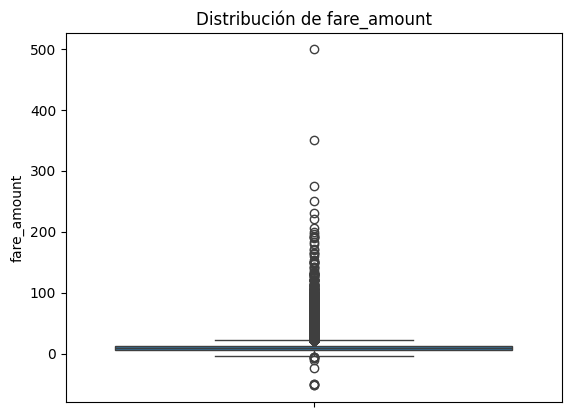

In [366]:
# Devido a que los errores representa un porcentaje muy bajo del dataset, decidimos imputar esos valores.
# Para ello vamos a observar como se distribuye el 'fare_amount' y tomar una desición sobre con qué métrica imputar

sns.boxplot(df['fare_amount'])
plt.title('Distribución de fare_amount')
plt.show()

In [367]:
# Ya que el porcentaje es muy bajo decidimos imputar esos valores faltantes usando la mediana

# Calculamos la mediana excluyendo los valores erroneos

median_fare = df[df['fare_amount'] > 0]['fare_amount'].median()

# Reemplazamos los valores erroneos por la mediana
df['fare_amount'] = df['fare_amount'].apply(lambda x: median_fare if x <= 0 else x)


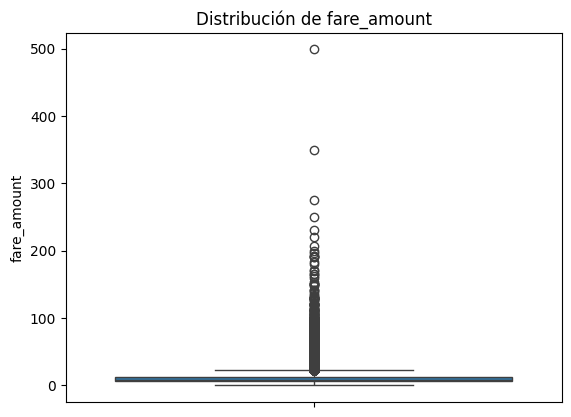

In [368]:
# Volvemos a visualizar variable target

sns.boxplot(df['fare_amount'])
plt.title('Distribución de fare_amount')
plt.show()

In [369]:
# Observamos los primeros datos

df['fare_amount'].sort_values()[:5]

,fare_amount
21658,0.01
191228,0.01
149342,0.11
141352,2.50
199658,2.50


Se puede observar que existen valores que no son exactamente cero, pero que siguen siendo errores de medición ya que se encuentran muy cercanos al cero.

Por tanto, también decidimos eliminarlos

In [370]:
# eliminamos esos 3 primeros datos cercanos a cero

df = df[df['fare_amount'] > 1]
df['fare_amount'].sort_values()[:5]

,fare_amount
60745,2.5
35294,2.5
130167,2.5
181433,2.5
35143,2.5


###Creación de features de interes

#### Calculo de la distancia de Haversine

In [371]:
import numpy as np

# Radio de la Tierra en kilómetros
R = 6371

# convertimos a radianes
df['pickup_latitude'] = np.radians(df['pickup_latitude'])
df['pickup_longitude'] = np.radians(df['pickup_longitude'])
df['dropoff_latitude'] = np.radians(df['dropoff_latitude'])
df['dropoff_longitude'] = np.radians(df['dropoff_longitude'])

# Realizamos la diferencia entre los radianes
delta_lat = df['dropoff_latitude'] - df['pickup_latitude']
delta_lon = df['dropoff_longitude'] - df['pickup_longitude']

# fórmula de Haversine
df['d_haversine'] = 2 * R * np.arcsin(np.sqrt(
    np.sin(delta_lat  / 2) ** 2 +
    np.cos(df['pickup_latitude']) * np.cos(df['dropoff_latitude']) *
    np.sin(delta_lon / 2) ** 2
))

# Unidad en kilometros

df['d_haversine'].head(3)

,d_haversine
0,1.683323
1,2.457590
2,5.036377


#### Tratamiento fecha. Obtención de nuevas características

In [372]:
#Convertimos la columna pickup_datetime en un tipo de dato correspondiente
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
#Fraccionamos la columna con fechas en: Mes, dia de semana y por hora
df['month'] = df['pickup_datetime'].dt.month
df['days_of_week'] = df['pickup_datetime'].dt.dayofweek
df['hour'] = df['pickup_datetime'].dt.hour

Trabajo con una copia para realizar un estudio preliminar de las nuevas features a realizar

In [373]:
#Creamos una copia del DF
df_copy = df.copy()

In [374]:
q99 = df_copy['fare_amount'].quantile(0.99)
df_copy = df_copy[df_copy['fare_amount'] <= q99]

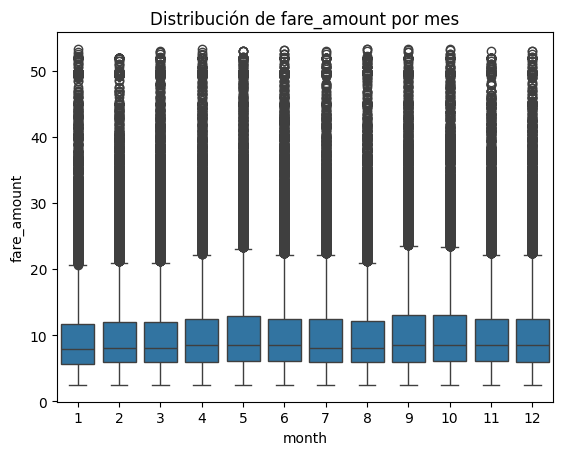

In [375]:
sns.boxplot( x='month', y='fare_amount', data=df_copy)
plt.title('Distribución de fare_amount por mes')
plt.show()

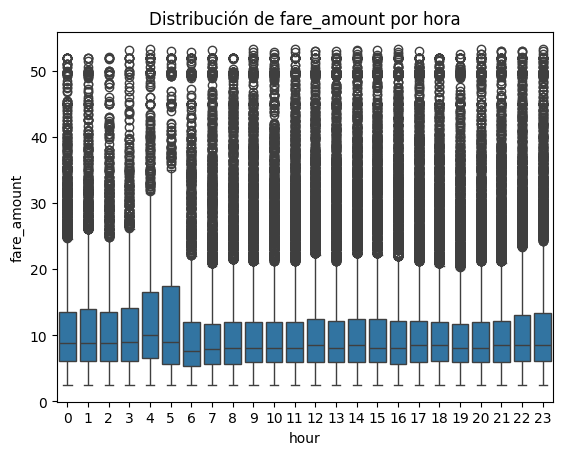

In [376]:
sns.boxplot( x='hour', y='fare_amount', data=df_copy)
plt.title('Distribución de fare_amount por hora')
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


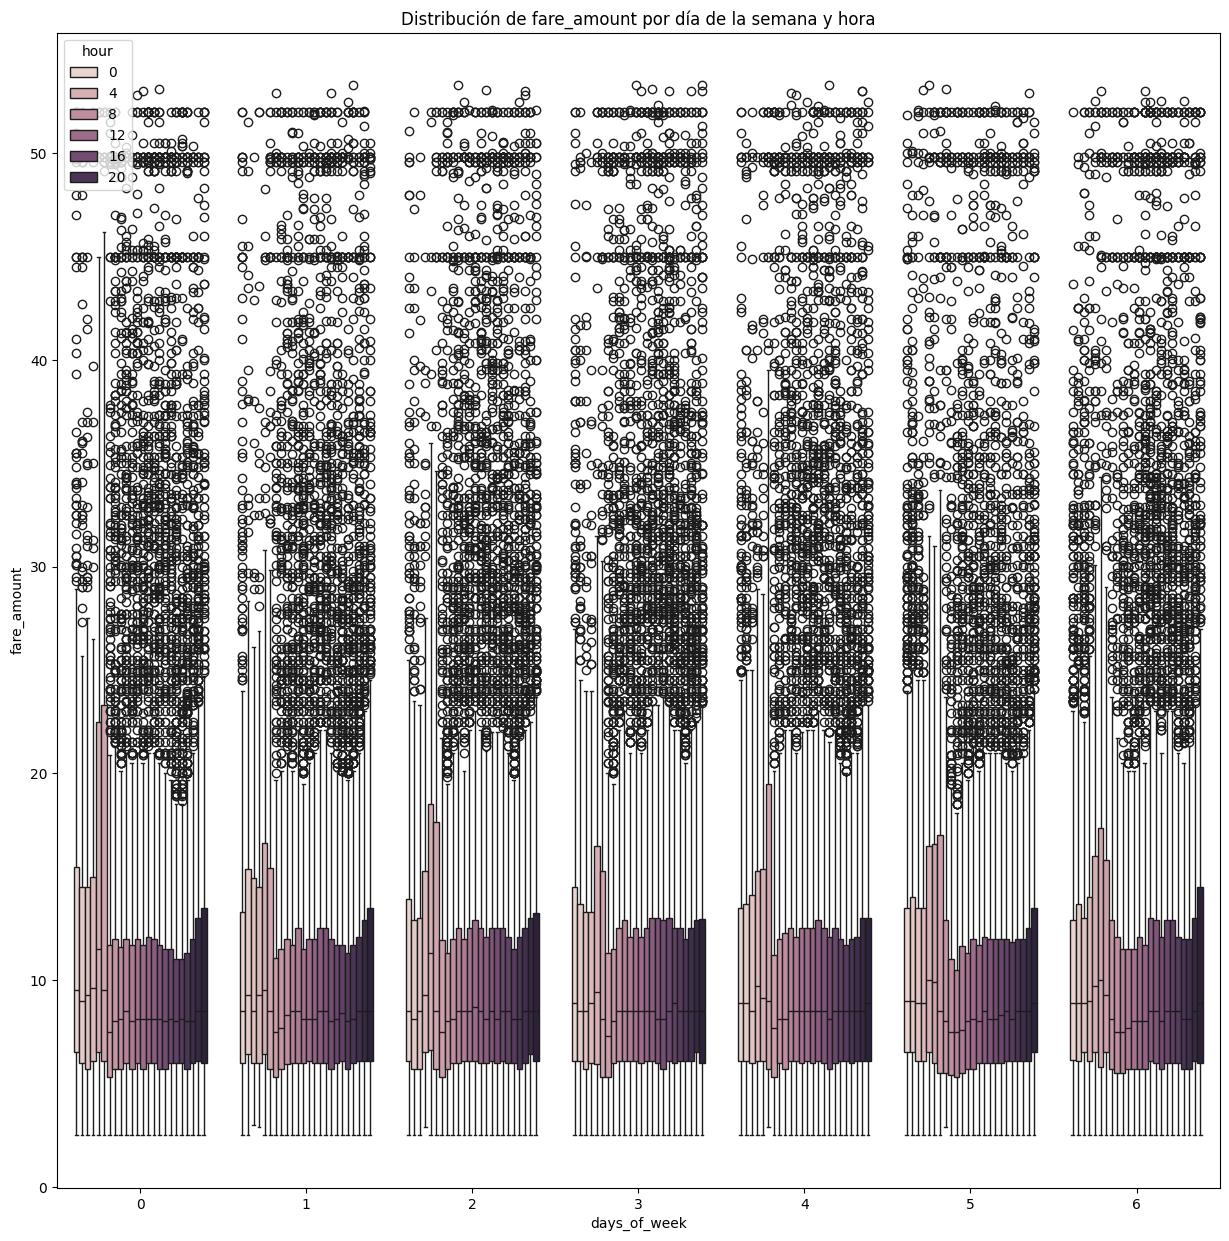

In [377]:
#Creamos grafico donde visualizamos como se distribuye la variable target a razon del dia segmentado por hora
plt.figure(figsize=(15,15))
sns.boxplot( x='days_of_week', y='fare_amount', data=df_copy, hue='hour')
plt.title('Distribución de fare_amount por día de la semana y hora')
plt.show()

Hipotesis preliminares:

Podemos identificar que existe una variabilidad significativa entre cada hora. Podríamos analizarlo como 'features' nuevas.


Los feriados podrían generarnos patrones de movilidad únicos, por lo tanto, vamos a diferenciarlos

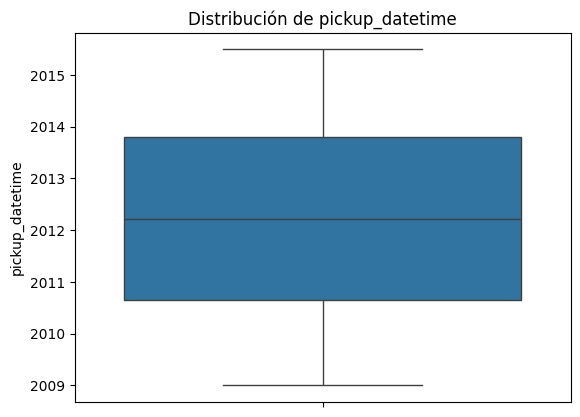

In [378]:
# Visualizamos la distribución de los años

sns.boxplot(df['pickup_datetime'])
plt.title('Distribución de pickup_datetime')
plt.show()

In [379]:
# vemos que la mediana se encuentra aproximadamente en 2012.Elegimimos el año 2012 para los feriados

feriados = holidays.US(years=[2012])

df['is_holiday'] = df['pickup_datetime'].dt.date.apply(lambda x: 1 if x in feriados else 0)

# visualizamos
df_holidays = df[df['is_holiday'] == 1]
print(df_holidays[['pickup_datetime', 'is_holiday']].head(10))

              pickup_datetime  is_holiday
22  2009-11-26 02:58:00+00:00           1
68  2015-02-16 11:19:55+00:00           1
170 2013-10-14 20:28:00+00:00           1
291 2010-01-01 20:33:00+00:00           1
375 2015-05-25 16:23:08+00:00           1
427 2010-07-04 17:10:17+00:00           1
431 2010-07-04 20:20:27+00:00           1
455 2012-07-04 17:39:45+00:00           1
497 2010-01-18 02:18:16+00:00           1
510 2011-01-17 11:45:00+00:00           1


Trabajamos sobre la feature 'passenger_count', clasificamos segun la cantidad de pasajeros

In [380]:
df['passenger_count'].unique()

array([  1,   3,   5,   2,   4,   6,   0, 208])

In [381]:
median_passenger = df['passenger_count'].median()

df['passenger_count'] = df['passenger_count'].apply(lambda x: median_passenger if x > 6 else int(x))

df['passenger_count'].unique()

array([1., 3., 5., 2., 4., 6., 0.])

In [382]:
def categorizacion_uber(pasajeros):
    if pasajeros == 0:
        return "envio"
    elif 1 <= pasajeros <= 4:
        return "uber"
    else:
        return "uberXL"

df['uber_trip'] = df['passenger_count'].apply(categorizacion_uber)

df['uber_trip'].unique()

array(['uber', 'uberXL', 'envio'], dtype=object)

In [383]:
#transformamos antes de dividir los datos
df['fare_amount'] = np.log1p(df['fare_amount'])

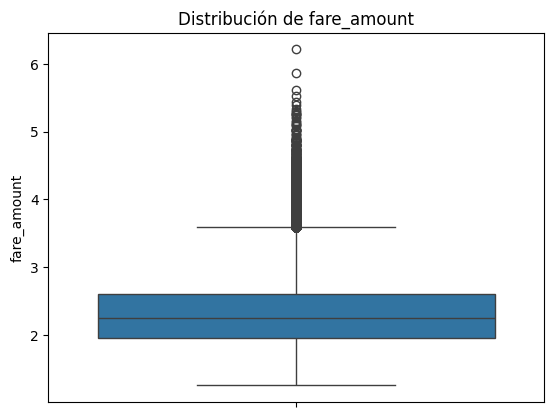

In [384]:
#Despues de aplicarle el logaritmo a la variable targuet volvemos a visualizar su distribucion
sns.boxplot(df['fare_amount'])
plt.title('Distribución de fare_amount')
plt.show()

###División del conjunto de datos

In [385]:
# Dividimos

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='fare_amount'), df['fare_amount'], test_size=0.2, random_state=42)

In [386]:
#Visualizamos informacion
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159997 entries, 66598 to 121959
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                159997 non-null  int64              
 1   date               159997 non-null  object             
 2   pickup_datetime    159997 non-null  datetime64[ns, UTC]
 3   pickup_longitude   159997 non-null  float64            
 4   pickup_latitude    159997 non-null  float64            
 5   dropoff_longitude  159996 non-null  float64            
 6   dropoff_latitude   159996 non-null  float64            
 7   passenger_count    159997 non-null  float64            
 8   d_haversine        159996 non-null  float64            
 9   month              159997 non-null  int32              
 10  days_of_week       159997 non-null  int32              
 11  hour               159997 non-null  int32              
 12  is_holiday         159997 non-n

###EDA (Análisis exploratorio de los datos)

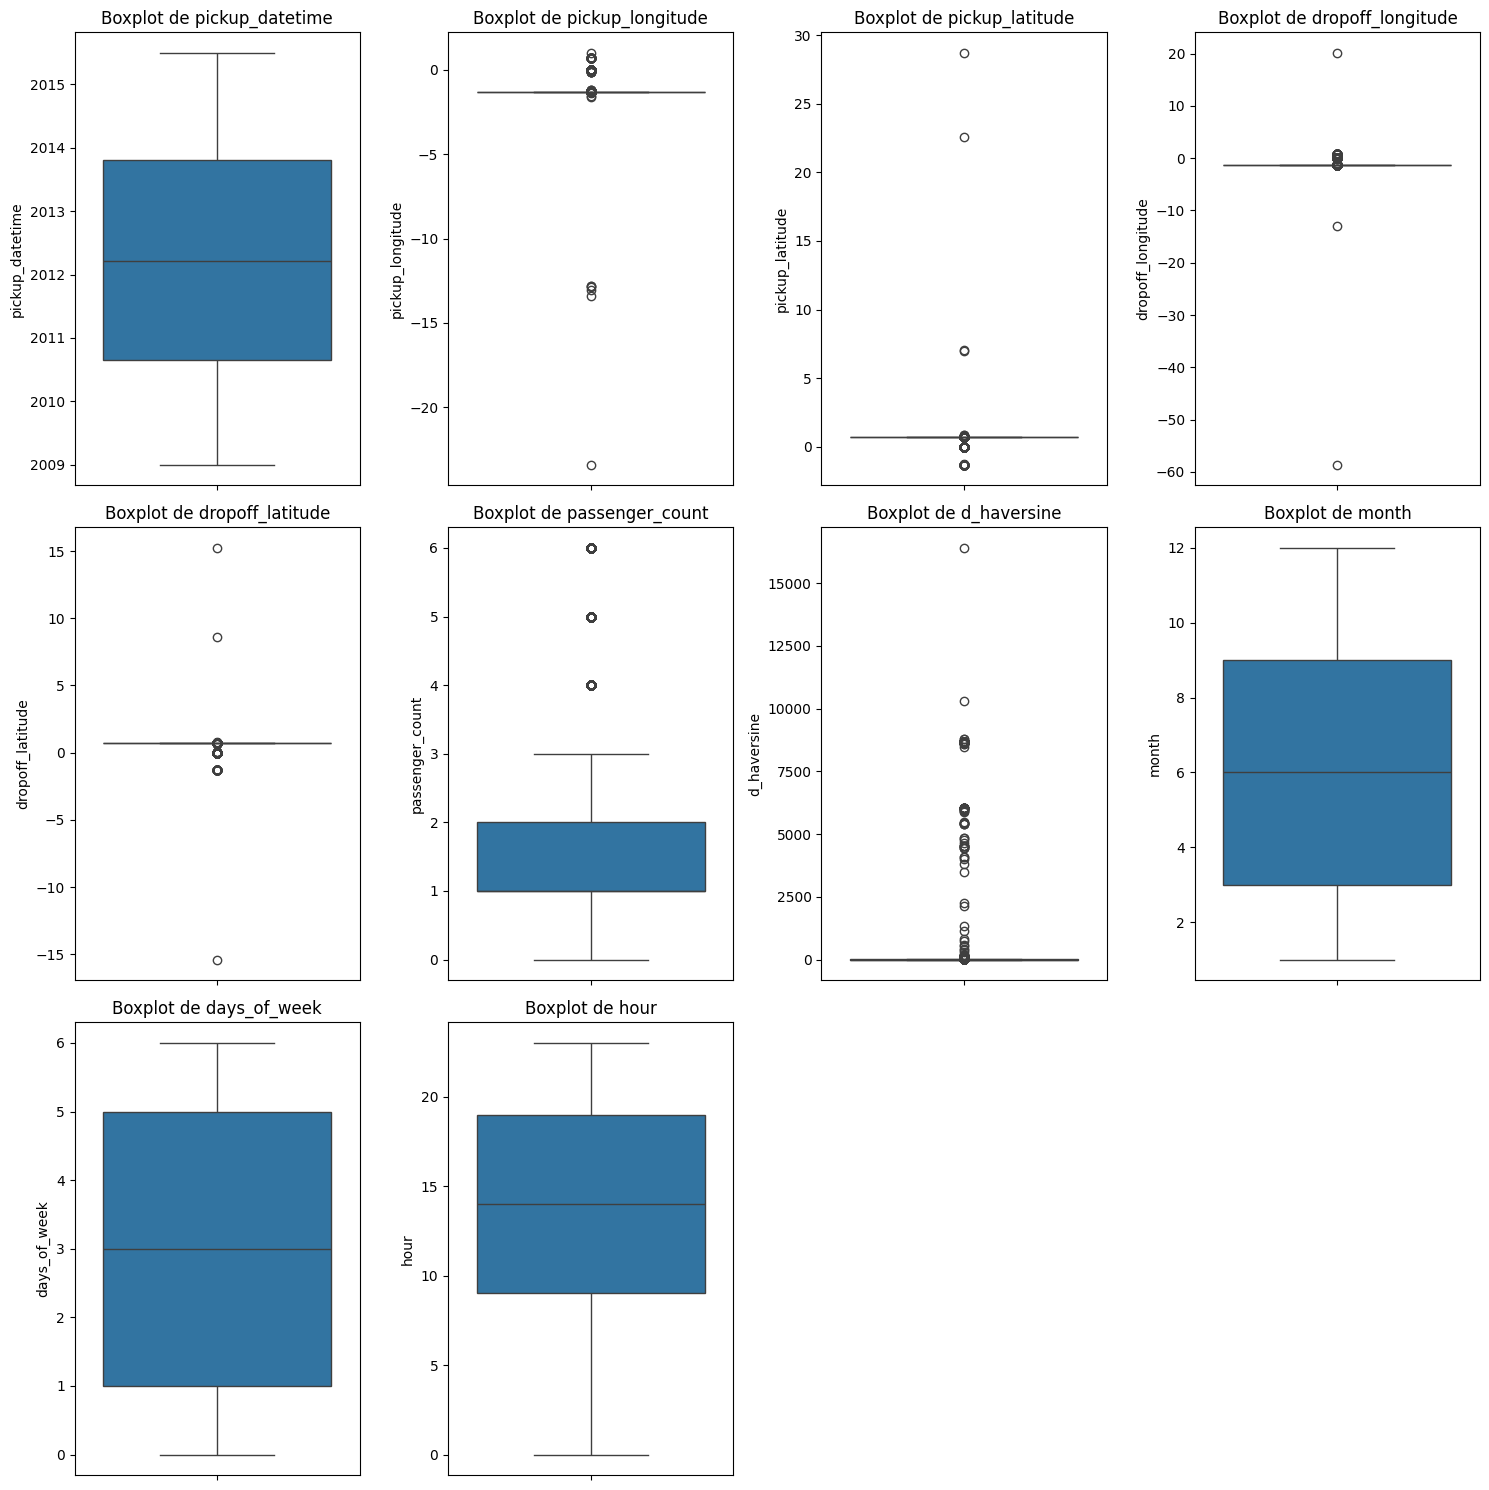

In [387]:
# Boxplot de las features

plt.figure(figsize=(15,15))
columnas = X_train.drop(columns=['key','date','is_holiday','uber_trip']).columns
for column in range(len(columnas)):
    plt.subplot(3, 4, column + 1)
    sns.boxplot(y=X_train[columnas[column]])
    plt.title(f'Boxplot de {columnas[column]}')
plt.tight_layout()
plt.show()

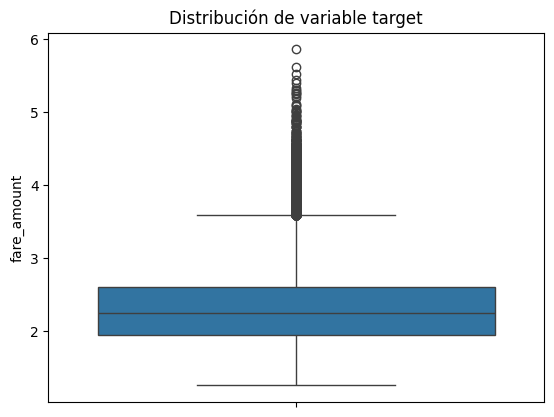

In [388]:
# Analisis de nuestra variable target

sns.boxplot(y_train)
plt.title('Distribución de variable target')
plt.show()

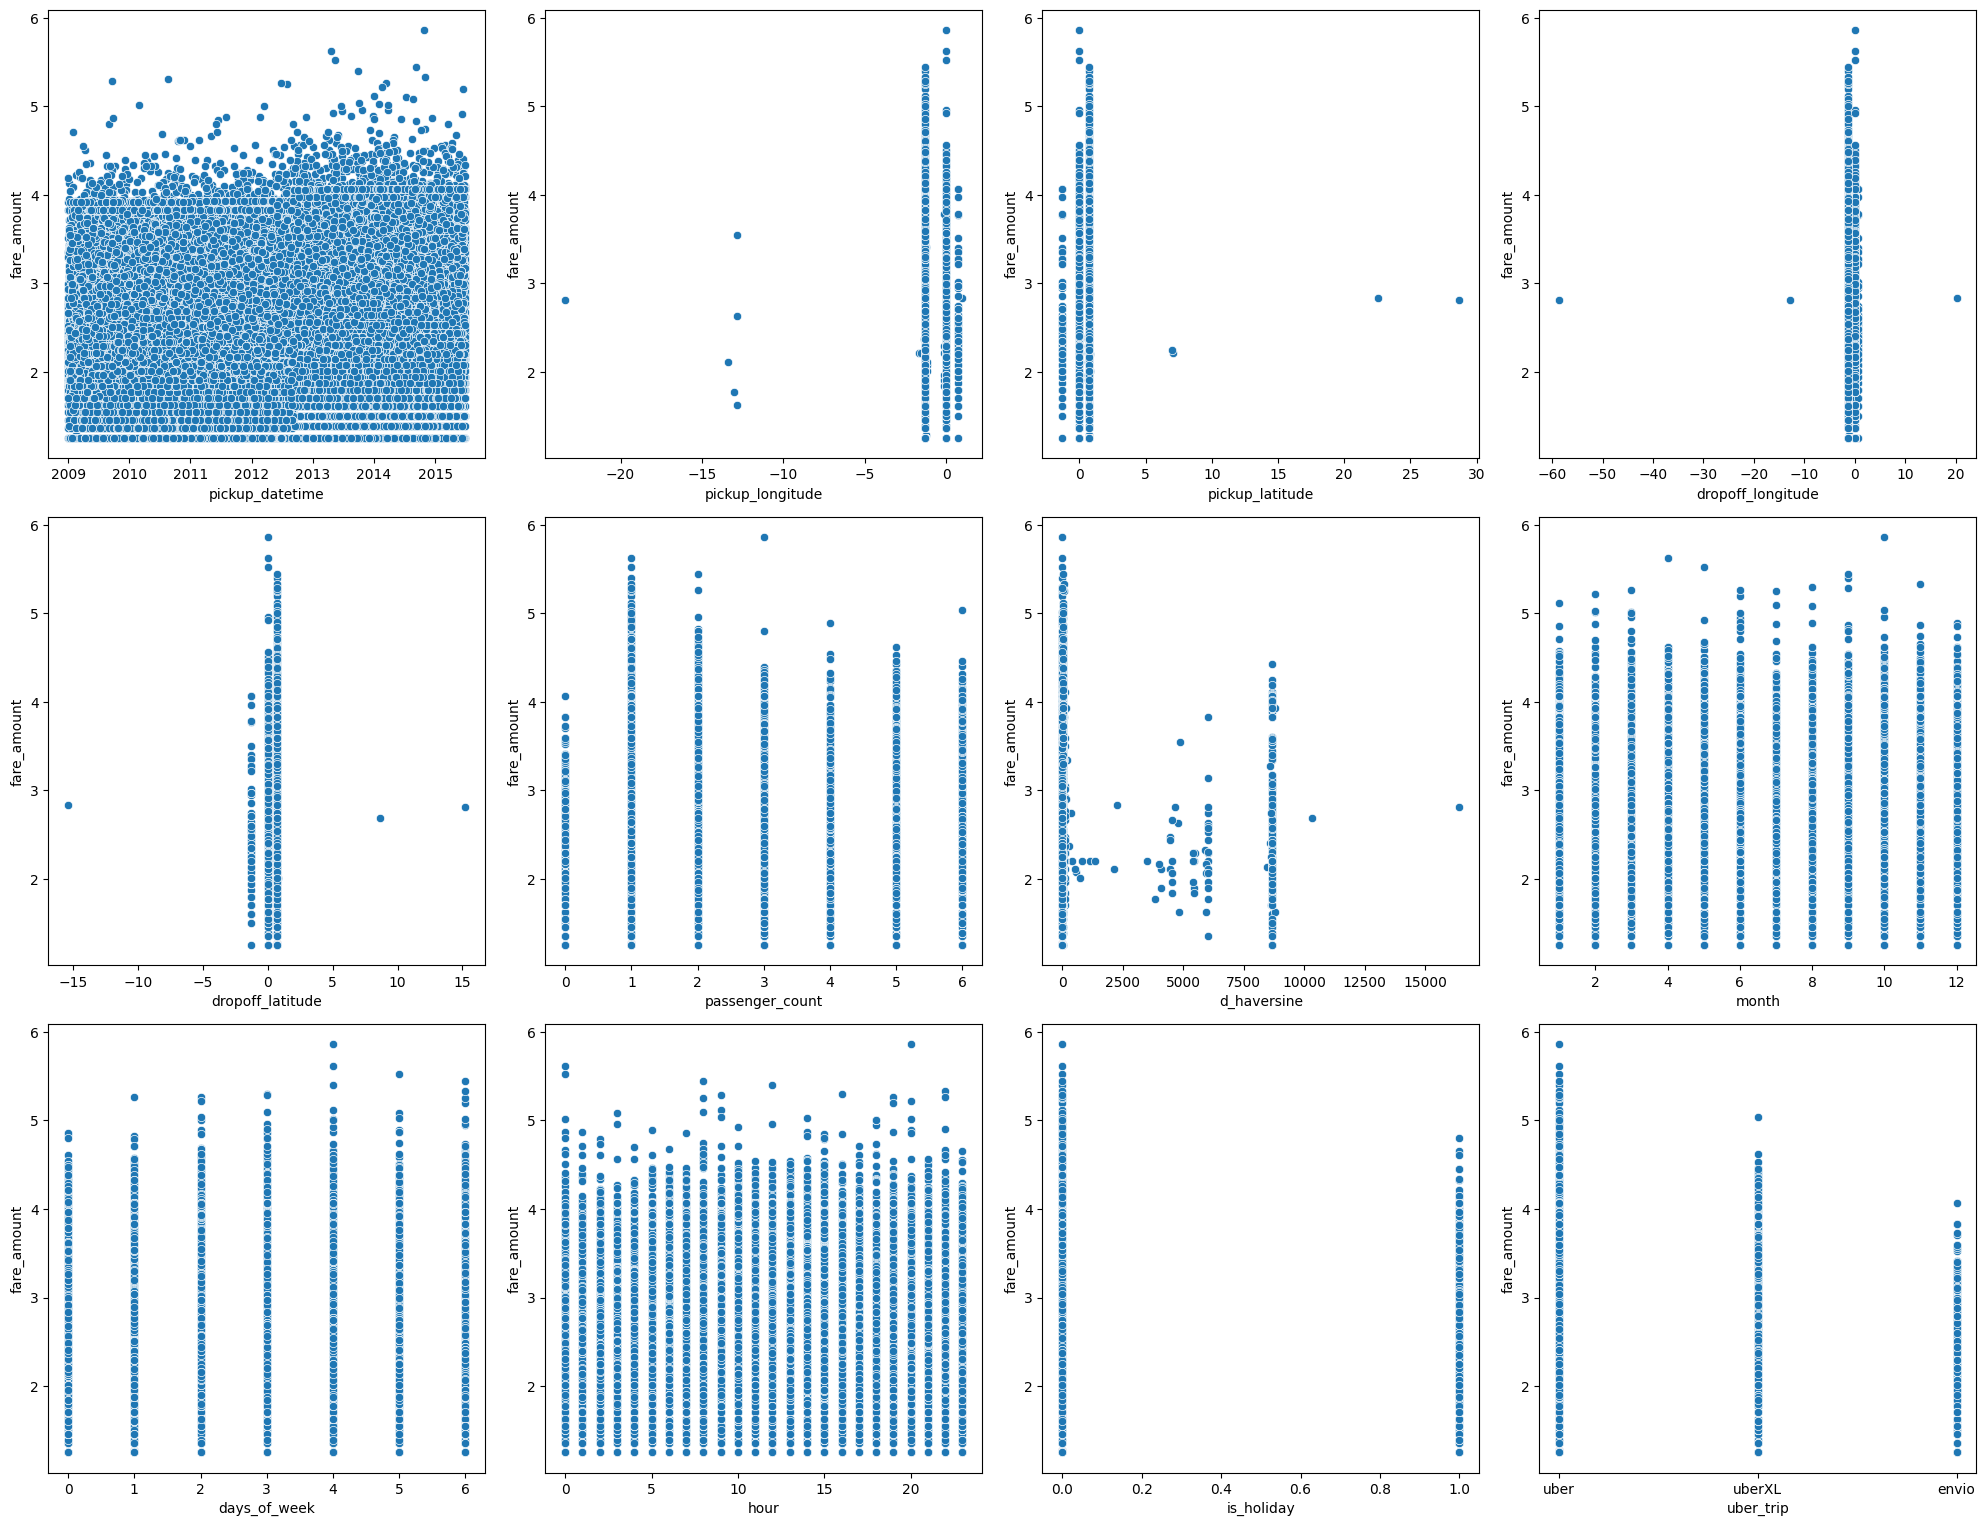

In [389]:
# Análisis de outliers respecto a fare_amount

columnas = X_train.drop(columns=['key','date']).columns

plt.figure(figsize=(20,20))

for column in range(len(columnas)):
    plt.subplot(4, 4, 1 + column)
    sns.scatterplot( x = X_train[columnas[column]], y = y_train)
plt.tight_layout()
plt.show()

In [390]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199997 entries, 0 to 199999
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                199997 non-null  int64              
 1   date               199997 non-null  object             
 2   fare_amount        199997 non-null  float64            
 3   pickup_datetime    199997 non-null  datetime64[ns, UTC]
 4   pickup_longitude   199997 non-null  float64            
 5   pickup_latitude    199997 non-null  float64            
 6   dropoff_longitude  199996 non-null  float64            
 7   dropoff_latitude   199996 non-null  float64            
 8   passenger_count    199997 non-null  float64            
 9   d_haversine        199996 non-null  float64            
 10  month              199997 non-null  int32              
 11  days_of_week       199997 non-null  int32              
 12  hour               199997 non-null 

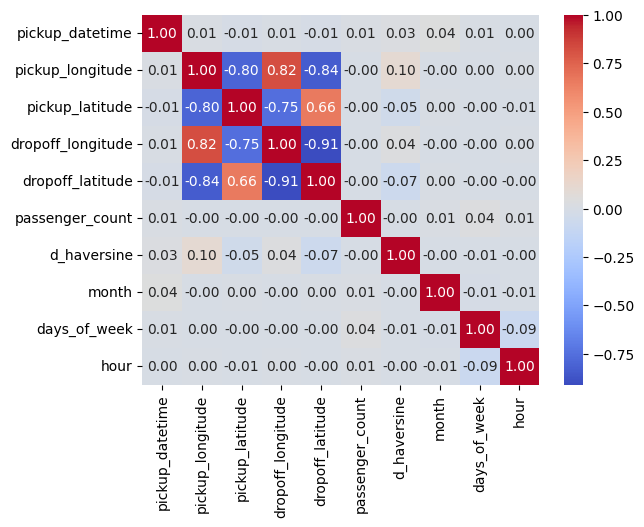

In [391]:
columns_exclude=['key','date','is_holiday', 'uber_trip']

sns.heatmap(X_train.drop(columns=columns_exclude).corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.show()

### Tratamiento de valores atipicos y datos faltantes

Nos quedamos con las variables de interés

In [392]:
X_train_sub = X_train.drop(columns=['pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude','key','date','pickup_datetime'])
print(X_train_sub.columns)

# Lo mismo para X_test

X_test_sub = X_test.drop(columns=['pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude','key','date','pickup_datetime'])
(X_test_sub.columns)

Index(['passenger_count', 'd_haversine', 'month', 'days_of_week', 'hour',
       'is_holiday', 'uber_trip'],
      dtype='object')


Index(['passenger_count', 'd_haversine', 'month', 'days_of_week', 'hour',
       'is_holiday', 'uber_trip'],
      dtype='object')

In [393]:
print("Análisis de datos faltantes en X_train:")

missing_data_train = pd.DataFrame({
    'Valores faltantes' : X_train_sub.isnull().sum(),
    'Porcentaje' : (X_train_sub.isnull().sum() / len(df)) * 100})
print(missing_data_train)

Análisis de datos faltantes en X_train:
                 Valores faltantes  Porcentaje
passenger_count                  0      0.0000
d_haversine                      1      0.0005
month                            0      0.0000
days_of_week                     0      0.0000
hour                             0      0.0000
is_holiday                       0      0.0000
uber_trip                        0      0.0000


In [394]:
print("Análisis de datos faltantes en X_test:")

missing_data_test = pd.DataFrame({
    'Valores faltantes' : X_test_sub.isnull().sum(),
    'Porcentaje' : (X_test_sub.isnull().sum() / len(df)) * 100})
print(missing_data_test)

Análisis de datos faltantes en X_test:
                 Valores faltantes  Porcentaje
passenger_count                  0         0.0
d_haversine                      0         0.0
month                            0         0.0
days_of_week                     0         0.0
hour                             0         0.0
is_holiday                       0         0.0
uber_trip                        0         0.0


Tratamiento del valor faltante en X_train_sub

In [395]:
# Obtenemos el índice del valor faltante en d_haversine
missing_index = X_train_sub[X_train_sub['d_haversine'].isna()].index

# Obtenemos el precio correspondiente a la distancia faltante usando su correspondiente índice
missing_fare = y_train.loc[missing_index].values[0]

In [396]:
# definir un rango de precios similares
precios_index = (y_train >= missing_fare - 3) & (y_train <= missing_fare + 3)

# calcular la mediana de las distancias en ese rango
mediana_rango = X_train_sub.loc[(precios_index) & (X_train_sub['d_haversine'] != 0), 'd_haversine'].median()

# imputamos el valor faltante de la distancia con la mediana del rango calculado
X_train_sub.loc[X_train_sub['d_haversine'].isna(), 'd_haversine'] = mediana_rango

In [397]:
mediana_rango

2.1871628841430266

#### Tratamiento de outliers

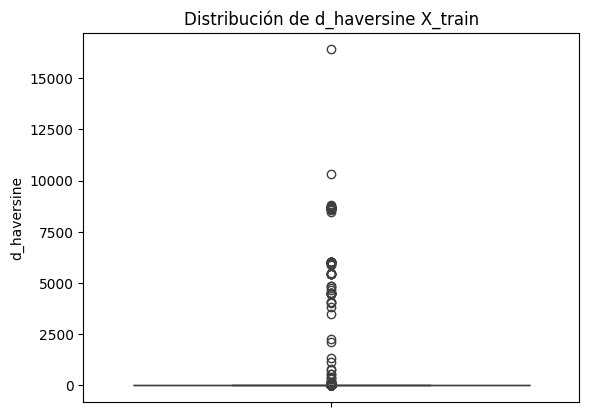

In [398]:
#Visualizamos la distancia en x_train para observar outliers
sns.boxplot(X_train_sub['d_haversine'])
plt.title('Distribución de d_haversine X_train')
plt.show()

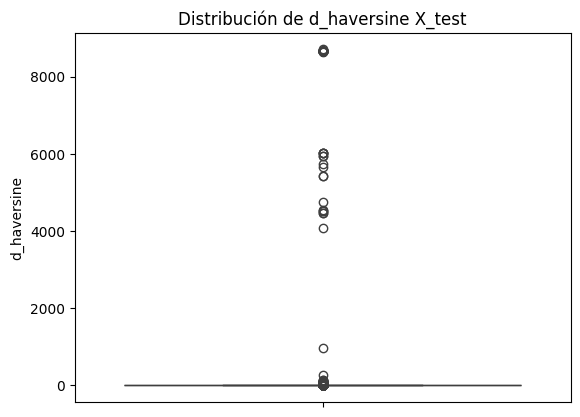

In [399]:
#Volvemos a visualizar la distancia pero en X_test
sns.boxplot(X_test_sub['d_haversine'])
plt.title('Distribución de d_haversine X_test')
plt.show()

Filtramos los datos quedándonos con las distancias menores al cuantil 0.99 para reducir el impacto de valores extremos que pueden afectar el entrenamiento del modelo.

El umbral se calcula únicamente con el conjunto de entrenamiento para evitar fugas de información. Aplicamos el mismo filtro a los conjuntos X_train, X_test, y_train y y_test para mantener la correspondencia entre las entradas y sus etiquetas.

Esto permite entrenar y evaluar el modelo bajo condiciones más representativas y consistentes.

In [400]:
# Se realiza un filtro en donde nos quedaremos con los indices que sean menores a el cuantil 0.99

#calculo del cuantil 0.99 en X_train_sub
q99_haversine = X_train_sub['d_haversine'].quantile(0.99)

# Filtro a X_train_sub
filtro_train = X_train_sub['d_haversine'] < q99_haversine
X_train_sub = X_train_sub[filtro_train]
#Filtramos y_train con la misma metodologia para no tener diferencia en observaciones
y_train = y_train[filtro_train]

# aplicamos el mismo filtro a X_test_sub
filtro_test = X_test_sub['d_haversine'] < q99_haversine
X_test_sub = X_test_sub[filtro_test]
y_test = y_test[filtro_test]


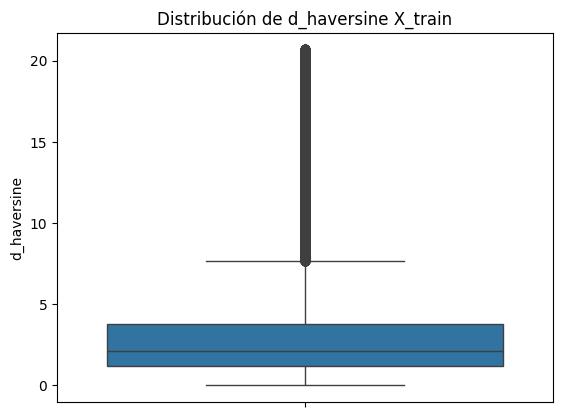

In [401]:
#Volvemos a graficar la distribucion de la distancia en X_train
sns.boxplot(X_train_sub['d_haversine'])
plt.title('Distribución de d_haversine X_train')
plt.show()

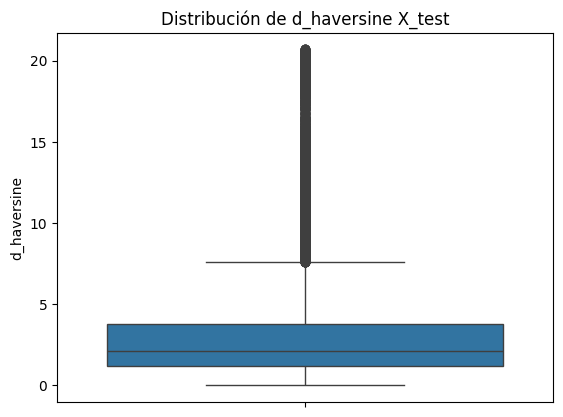

In [402]:
#Grafico de distribucion de la distancia en x_test
sns.boxplot(X_test_sub['d_haversine'])
plt.title('Distribución de d_haversine X_test')
plt.show()

Tratamiento de las distancias menores o iguales a cero

In [403]:
# Contar cuantos valores son iguales o menor a 0

print((X_train_sub['d_haversine'] <= 0).sum())
print((X_test_sub['d_haversine'] <= 0).sum())

4537
1095


In [404]:
# Imputamos los valores que son iguales o menos a 0, por la mediana sin tener en cuenta los valores iguales a 0

mediana_sin_ceros = X_train_sub.loc[X_train_sub['d_haversine'] > 0, 'd_haversine'].median()
#Imputamos los valores menores o igual a cero por la mediana de x_train
X_train_sub.loc[X_train_sub['d_haversine'] <= 0, 'd_haversine'] = mediana_sin_ceros

#imputamos los valores de x_test por la mediana de x_train

X_test_sub.loc[X_test_sub['d_haversine'] <= 0, 'd_haversine'] = mediana_sin_ceros

In [405]:
# Contar cuantos valores son iguales o menor a 0
print('La cantidad de observaciones en la distancia que son igual o menores a cero son:')
print((X_train_sub['d_haversine'] <= 0).sum())
print((X_test_sub['d_haversine'] <= 0).sum())


La cantidad de observaciones en la distancia que son igual o menores a cero son:
0
0


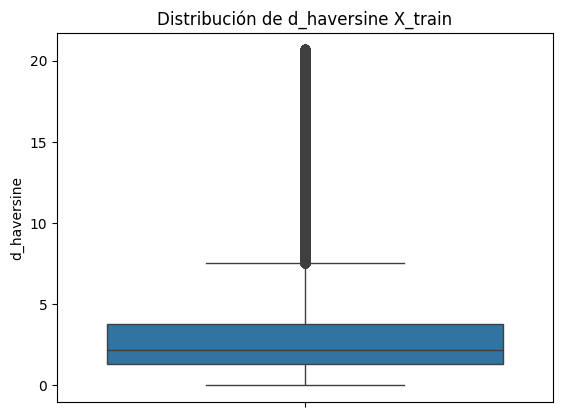

In [406]:
#Volvemos a visualizar la distribucion de la distancia
sns.boxplot(X_train_sub['d_haversine'])
plt.title('Distribución de d_haversine X_train')
plt.show()

#### Escalado , OneHotEncoder y Pipeline

Aclaración:

La variable hour, aunque originalmente representada como un número entero entre 0 y 23, no tiene una relación lineal con el precio. Es decir, no hay una razón para asumir que la diferencia entre las 10 y las 11 sea equivalente a la diferencia entre las 2 y las 3 en cuanto al impacto en el precio del viaje.



Además, al analizar los datos previamente, se observó una variación significativa en los precios según la hora del día, lo cual sugiere la presencia de patrones horarios, como picos de demanda en horarios laborales o nocturnos.



Por este motivo, se decidimos tratar hour como una variable categórica, aplicando codificación One Hot Encoding para capturar adecuadamente los efectos específicos de cada franja horaria en el modelo.

In [407]:
# Modificamos el tipo de datos en hour y uber_trip

X_train_sub[['hour', 'uber_trip']] = X_train_sub[['hour', 'uber_trip']].astype('category')
X_test_sub[['hour', 'uber_trip']] = X_test_sub[['hour', 'uber_trip']].astype('category')

In [408]:
# Clasificamos por tipo de datos para posteriori escalado

# Son las mimas para X_train y X_test, asi que elegimos cualquiera de las dos
columnas_numéricas = X_train_sub.select_dtypes(include=['int64', 'float64']).columns
columnas_categóricas = X_train_sub.select_dtypes(include=['category']).columns

In [409]:
columnas_categóricas

Index(['hour', 'uber_trip'], dtype='object')

In [410]:
# Escalamos

prepocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numéricas),
        ('cat', OneHotEncoder(drop='first'), columnas_categóricas) # Para variables categóricas, utilizamos OHE
    ])

In [411]:
# Pipeline

pipeline = Pipeline(steps=[
    ('prepocesador', prepocesador),
    ('lr', LinearRegression())
])

In [412]:
# Predicciones y evaluación

pipeline.fit(X_train_sub, y_train)

# pipeline.fit -> realiza un fit_transform ( realiza el cálculo del escalado y luego lo aplica sobre cada dato
# ademas hace un ajuste de los coef en funcion de los datos transformados(X_train_sub) y los valores verdaderos (y_train))

y_pred_train = pipeline.predict(X_train_sub) # pipeline internamente con .predict SOLO realiza un transform, además del OHE y la regresión ( predecimos valores con X_train).
y_pred_test = pipeline.predict(X_test_sub) # pipeline internamente con .predict SOLO realiza un transform, además del OHE y la regresión ( predecimos valores con X_test).

#### Regresión Lineal

In [413]:
# Visualizamos las columnas transformadas
pipeline.named_steps['prepocesador'].get_feature_names_out()

array(['num__passenger_count', 'num__d_haversine', 'num__is_holiday',
       'cat__hour_1', 'cat__hour_2', 'cat__hour_3', 'cat__hour_4',
       'cat__hour_5', 'cat__hour_6', 'cat__hour_7', 'cat__hour_8',
       'cat__hour_9', 'cat__hour_10', 'cat__hour_11', 'cat__hour_12',
       'cat__hour_13', 'cat__hour_14', 'cat__hour_15', 'cat__hour_16',
       'cat__hour_17', 'cat__hour_18', 'cat__hour_19', 'cat__hour_20',
       'cat__hour_21', 'cat__hour_22', 'cat__hour_23',
       'cat__uber_trip_uber', 'cat__uber_trip_uberXL'], dtype=object)

In [414]:
# Obtenemos los coeficientes de X_train_sub -> el modelo entrenado

coeficientes = pipeline.named_steps['lr'].coef_
print(coeficientes)

[ 1.35223180e-02  4.33995048e-01 -6.36730215e-03 -1.37668279e-02
 -2.41375940e-02 -2.00882659e-02 -2.18223999e-02 -6.10683081e-02
 -7.66997073e-02 -1.69897938e-02  3.53505076e-02  5.29906215e-02
  4.58519523e-02  4.88365197e-02  5.84217091e-02  4.50449309e-02
  5.26459973e-02  4.97650512e-02  2.52353809e-02  4.36005924e-02
  3.95429120e-02  2.33308094e-02 -3.62648541e-05 -3.66412943e-03
  5.01255393e-03  5.60111217e-03  6.70760483e-02  3.44285327e-02]


In [415]:
# Obtenemos los valores de RMSE Y R2 para X_train y X_test

# RMSE y R2 para datos de entrenamiento
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

# RMSE y R2 para datos de prueba
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

# Instanciamos un diccionario con las metricas ( lo usaremos despues )
metricas_lr = {
    'rmse_train': rmse_train,
    'r2_train': r2_train,
    'rmse_test': rmse_test,
    'r2_test': r2_test
}

# Mostramos los resultados
print(f"RMSE en entrenamiento: {rmse_train:.2f}")
print(f"R2 en entrenamiento: {r2_train:.2f}")
print(f"\nRMSE en prueba: {rmse_test:.2f}")
print(f"R2 en prueba: {r2_test:.2f}")


RMSE en entrenamiento: 0.30
R2 en entrenamiento: 0.67

RMSE en prueba: 0.30
R2 en prueba: 0.67


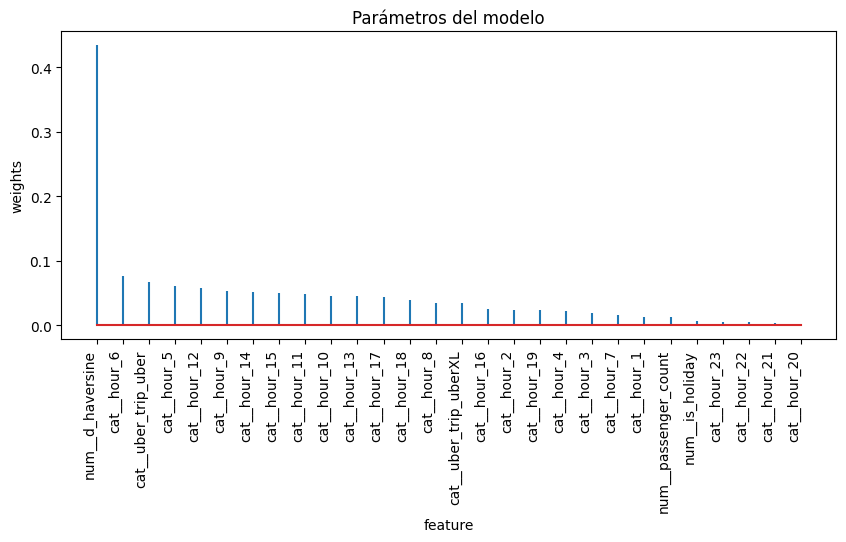

In [416]:
# Coeficientes del modelo

df_coeficientes = pd.DataFrame({'Variable': pipeline.named_steps['prepocesador'].get_feature_names_out(), 'Coeficientes': abs(pipeline.named_steps['lr'].coef_)}).sort_values(by='Coeficientes', ascending=False)
# Graficamos

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(df_coeficientes.Variable, df_coeficientes.Coeficientes, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('feature')
ax.set_ylabel('weights')
ax.set_title('Parámetros del modelo')
plt.show()


Gráfico de los residuos

In [417]:
y_pred_test = y_pred_test.reshape(-1, 1)
y_test = y_test.to_numpy().reshape(-1, 1)


In [418]:
print(y_pred_test.shape)
print(y_test.shape)

(39571, 1)
(39571, 1)


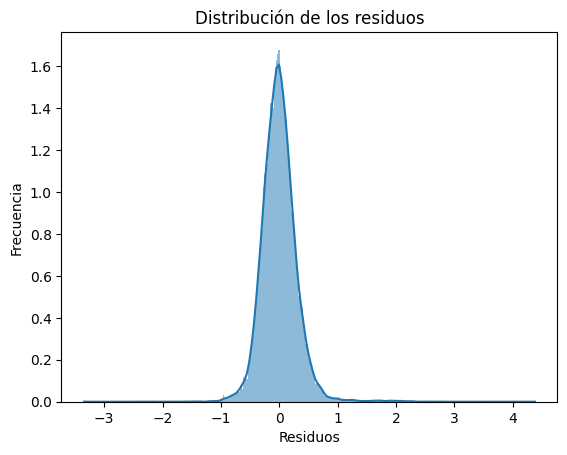

In [419]:

residuos = y_test - y_pred_test

# Gráfico de distribución de los residuos
sns.histplot(data=(residuos), color="red", kde=True, stat="density", linewidth=0, legend=False)
plt.title("Distribución de los residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()


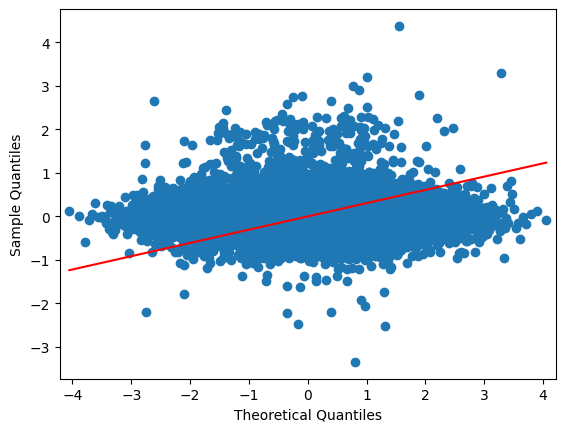

In [420]:
# QQ Plot
sm.qqplot(data=(residuos), line='s')
plt.show()

Podemos ver que los residuos no siguen una distribución normal.

Se observa que los puntos no siguen una linea recta, especialmente en el extremo superior.

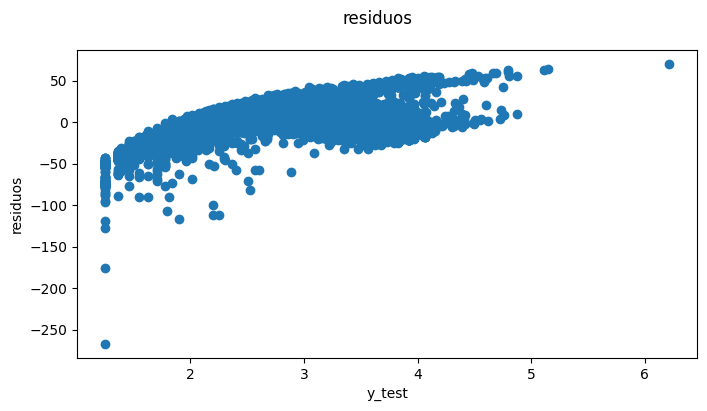

In [421]:
# Grafico de los errores relativos
fig = plt.figure(figsize=(8,4))
fig.suptitle('residuos')
plt.xlabel('y_test')
plt.ylabel('residuos')
plt.scatter(y_test,100*(residuos/y_test))
plt.show()

En un modelo ideal, esperaríamos que los residuos se distribuyan de forma aleatoria, sin presencia de patrones específicos.

Podemos observar una gran variabilidad en los residuos en valores bajos de y_test. Podría deverse a que en esos casos son atípicos o el modelo no está capturando bien.

### Gradiente descendiente

#### Preparamos los datos

In [422]:
# obtenemos los datos procesados del Pipeline
X_train_scaler = pipeline.named_steps['prepocesador'].transform(X_train_sub)
X_test_scaler = pipeline.named_steps['prepocesador'].transform(X_test_sub)
X_train_scaler = X_train_scaler.toarray()
X_test_scaler = X_test_scaler.toarray()

# Obtenemos el nombre de las columnas ( lo utilizaremos en las graficas posteriores )
feature_names = pipeline.named_steps['prepocesador'].get_feature_names_out()

In [423]:
print(X_train_scaler.shape)
print(X_test_scaler.shape)
print(y_test.shape)
print(y_train.shape)


(158397, 28)
(39571, 28)
(39571, 1)
(158397,)


In [424]:
y_train = y_train.to_numpy().reshape(-1, 1)

In [425]:
print(y_train.shape)

(158397, 1)


#### Funciones

In [426]:
def gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, graph=True):
    """
    shapes:
        X_train = nxm
        y_train = nx1
        X_test = pxm
        y_test = px1
        W = mx1
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_test.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((o, 1)), X_test))


    # Inicializar pesos aleatorios
    W = np.random.randn(m+1).reshape(m+1, 1) * 0.01

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        #print(error_train)
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_test, W)
        error_test = y_test - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum  # 1xm
        gradient = np.transpose(grad_mul).reshape(-1, 1)  # mx1

        W = W - (lr * gradient)

    if graph:
      # Graficar errores de entrenamiento y prueba
      # Definir una figura
      plt.figure(figsize=(12, 6))
      # Plotear errores de entrenamiento
      plt.plot(train_errors, label='Error de entrenamiento')
      # Plotear errores de prueba
      plt.plot(test_errors, label='Error de prueba')
      # Poner labels en los ejes
      plt.xlabel('Época')
      plt.ylabel('Error cuadrático medio')
      # Activar la leyenda
      plt.legend()
      # Poner titulo
      plt.title('Error de entrenamiento y prueba vs iteraciones (GD)')
      # Terminar y mostrar gráfico
      plt.show()

    return W

In [427]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):

    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m+1).reshape(m+1, 1) * 0.01

    train_errors = []
    test_errors = []

    for i in range(epochs):
        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            # Obtener una muestra aleatoria de un solo dato para hacer SGD
            x_sample = X_train[j]
            y_sample = y_train[j][0]

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction
            train_mse = error ** 2
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            gradient = -2 * error * x_sample.T.reshape(-1, 1)

            W = W - (lr * gradient)



    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.show()

    return W

In [428]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=None):
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m+1).reshape(m+1, 1) * 0.01

    train_errors = []
    test_errors = []

    for i in range(epochs):

        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            # Obtener un lote (mini-batch) de datos
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W

In [429]:
def evaluar_modelo(coef, X_train_scaler, X_test_scaler, y_train, y_test, pipeline, titulo='Modelo'):
    """
    Calcula métricas de evaluación y grafica los coeficientes de un modelo lineal entrenado.

    """

    # Agregar columna de unos
    X_train_bias = np.hstack((np.ones((X_train_scaler.shape[0], 1)), X_train_scaler))
    X_test_bias = np.hstack((np.ones((X_test_scaler.shape[0], 1)), X_test_scaler))

    # Predicciones
    y_pred_train = X_train_bias @ coef
    y_pred_test = X_test_bias @ coef

    # Aplanar vectores
    y_train_flat = y_train.flatten()
    y_test_flat = y_test.flatten()
    y_pred_train_flat = y_pred_train.flatten()
    y_pred_test_flat = y_pred_test.flatten()

    # Métricas
    rmse_train = np.sqrt(mean_squared_error(y_train_flat, y_pred_train_flat))
    r2_train = r2_score(y_train_flat, y_pred_train_flat)

    rmse_test = np.sqrt(mean_squared_error(y_test_flat, y_pred_test_flat))
    r2_test = r2_score(y_test_flat, y_pred_test_flat)

    # Mostrar métricas
    print(f"{titulo} - Entrenamiento → RMSE: {rmse_train:.4f} | R²: {r2_train:.4f}")
    print(f"{titulo} - Test         → RMSE: {rmse_test:.4f} | R²: {r2_test:.4f}")

    # Coeficientes
    df_coef = pd.DataFrame({
        'predictor': feature_names,
        'Coeficientes': np.abs(coef[1:].flatten())
    }).sort_values(by='Coeficientes', ascending=False)

    print(f"\nOrdenada al origen: {coef[0][0]:.4f}")

    # Gráfico
    plt.figure(figsize=(12, 5))
    plt.stem(df_coef.predictor, df_coef.Coeficientes, markerfmt=' ')
    plt.xticks(rotation=90, ha='right', size=9)
    plt.xlabel('Variables')
    plt.ylabel('Pesos (absolutos)')
    plt.title(f'Coeficientes del modelo ({titulo})')
    plt.tight_layout()
    plt.show()

    return  {
        'rmse_train': rmse_train,
        'r2_train': r2_train,
        'rmse_test': rmse_test,
        'r2_test': r2_test,
        'y_train_flat': y_train_flat,
        'y_pred_train_flat': y_pred_train_flat,
        'y_test_flat': y_test_flat,
        'y_pred_test_flat': y_pred_test_flat
    }


#### Gradient Descent

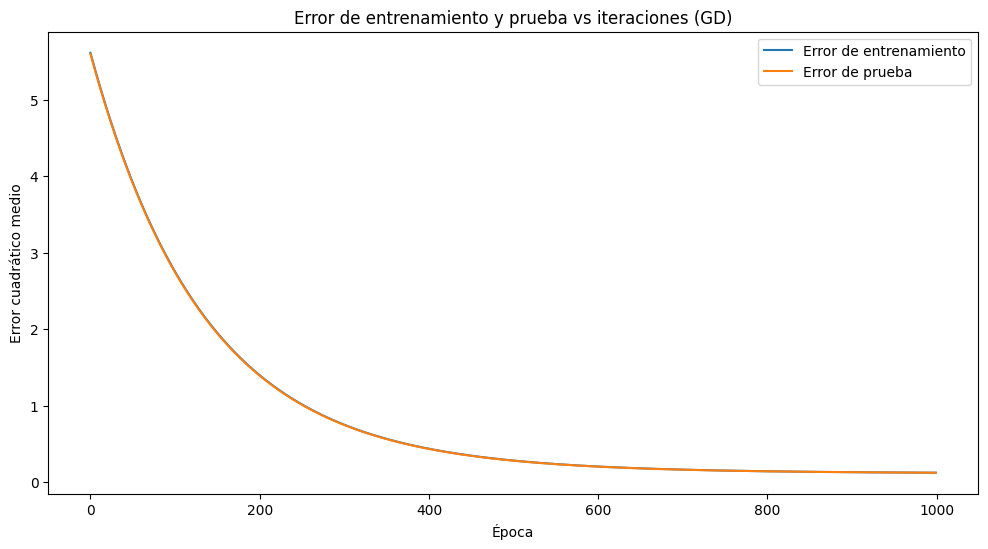

In [430]:
gd_coef = gradient_descent(X_train_scaler, y_train, X_test_scaler, y_test, epochs=1000, lr=0.001)

In [431]:
gd_coef

array([[ 1.24003153],
       [ 0.16393078],
       [ 0.37117434],
       [-0.00272939],
       [ 0.04378428],
       [ 0.02801649],
       [ 0.02072527],
       [ 0.018648  ],
       [ 0.01119623],
       [ 0.02188656],
       [ 0.04523691],
       [ 0.0517615 ],
       [ 0.0576393 ],
       [ 0.05351043],
       [ 0.06782879],
       [ 0.07501002],
       [ 0.07035887],
       [ 0.04439904],
       [ 0.05981691],
       [ 0.04635195],
       [ 0.06772392],
       [ 0.06757865],
       [ 0.06932556],
       [ 0.08656399],
       [ 0.07541636],
       [ 0.06355989],
       [ 0.08033505],
       [ 1.03271853],
       [ 0.20050113]])

Gradiente Descendiente - Entrenamiento → RMSE: 0.3499 | R²: 0.5624
Gradiente Descendiente - Test         → RMSE: 0.3498 | R²: 0.5635

Ordenada al origen: 1.2400


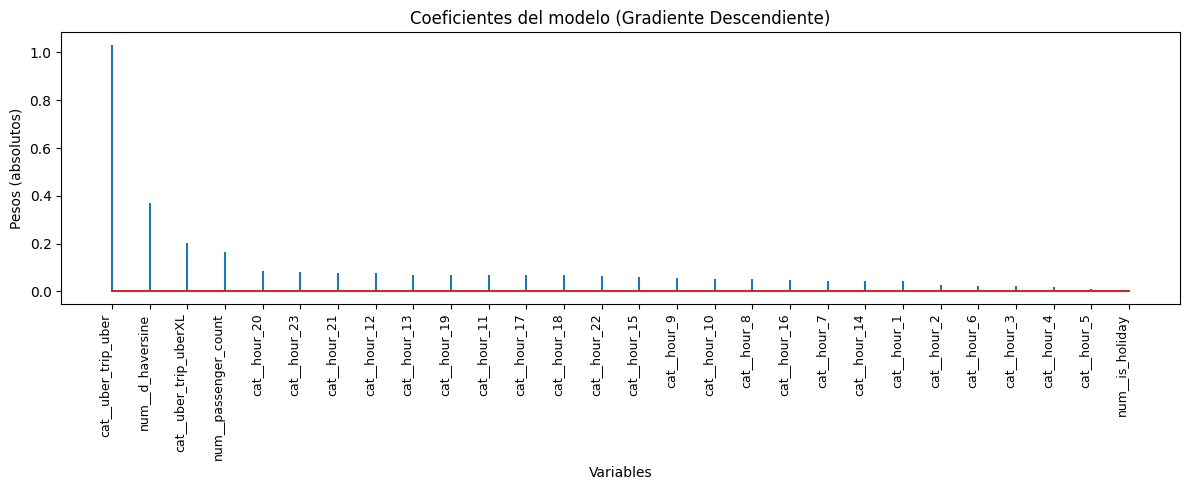

In [432]:
metricas_gd = evaluar_modelo(gd_coef, X_train_scaler, X_test_scaler, y_train, y_test, pipeline, titulo='Gradiente Descendiente')

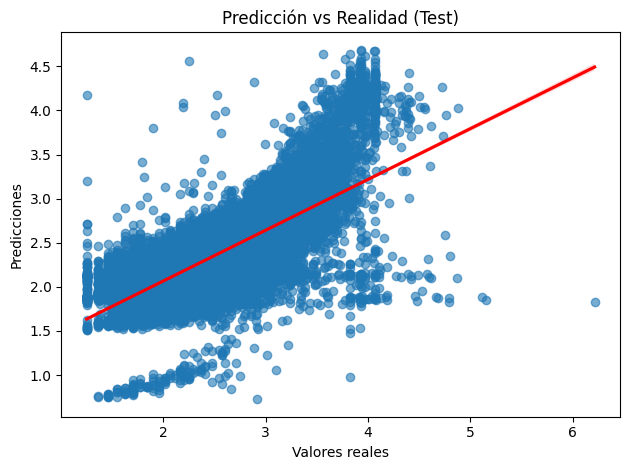

In [433]:
sns.regplot(x=metricas_gd['y_test_flat'], y=metricas_gd['y_pred_test_flat'], line_kws={'color': 'red'}, scatter_kws={'alpha':0.6})
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicción vs Realidad (Test)")
plt.tight_layout()
plt.show()


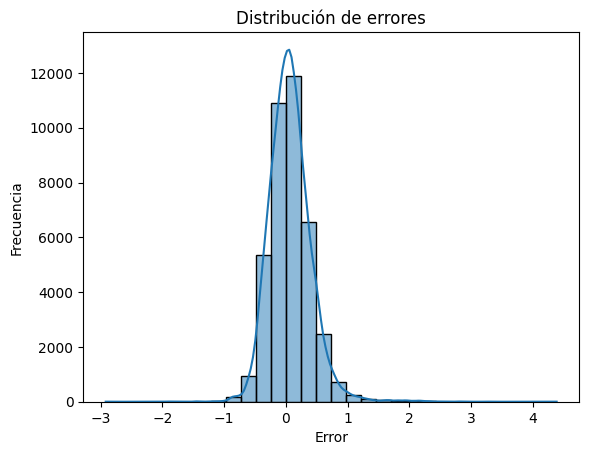

In [434]:
# Distribución de los errores Test
errores = metricas_gd['y_test_flat'] - metricas_gd['y_pred_test_flat']
sns.histplot(errores, kde=True, bins=30)
plt.title("Distribución de errores")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()


#### Stochastic Gradient Descent

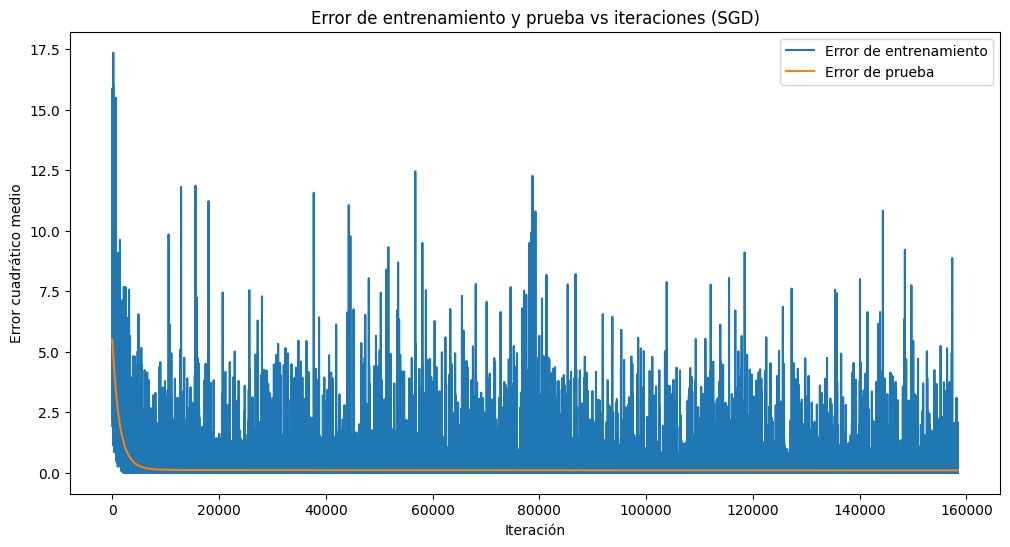

In [435]:
sgd_coef = stochastic_gradient_descent(X_train_scaler, y_train, X_test_scaler, y_test, lr=0.0001, epochs=1)

Gradiente Descendiente Estocástico - Entrenamiento → RMSE: 0.3113 | R²: 0.6538
Gradiente Descendiente Estocástico - Test         → RMSE: 0.3116 | R²: 0.6537

Ordenada al origen: 1.4460


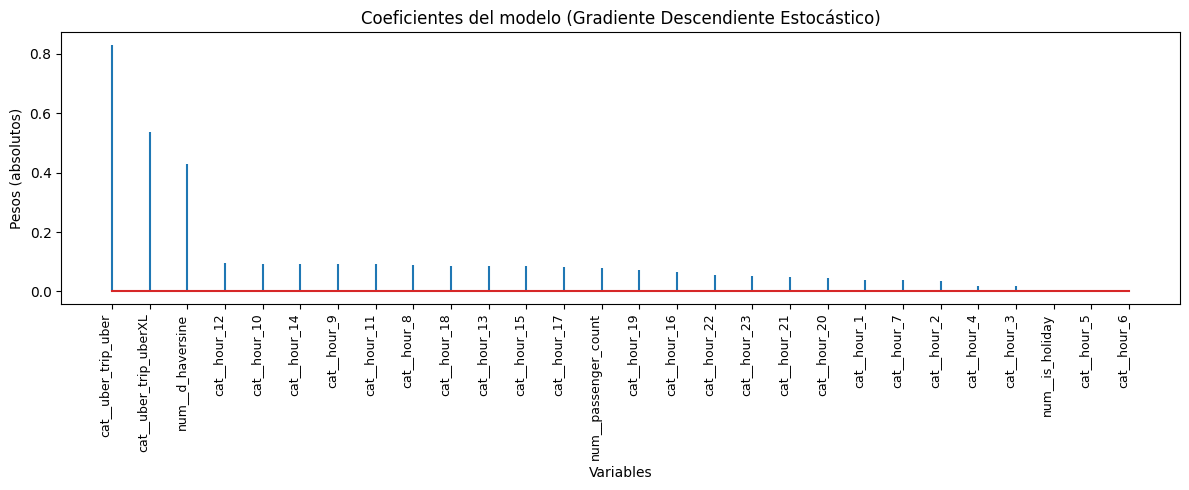

In [436]:
metricas_sgd = evaluar_modelo(sgd_coef, X_train_scaler, X_test_scaler, y_train, y_test, pipeline, titulo='Gradiente Descendiente Estocástico')

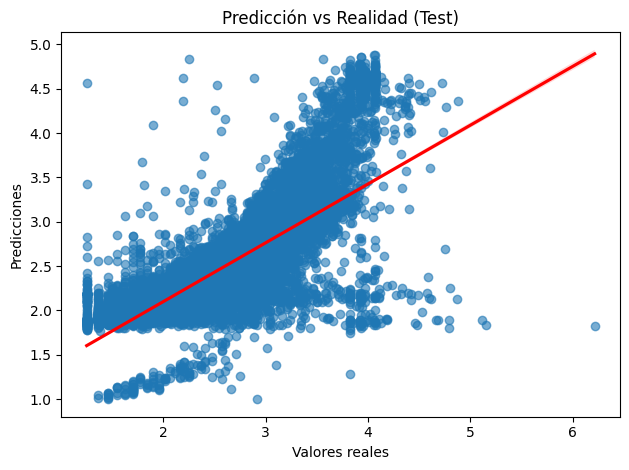

In [437]:
# Predicción vs Realidad
sns.regplot(x=metricas_sgd['y_test_flat'], y=metricas_sgd['y_pred_test_flat'], line_kws={'color': 'red'}, scatter_kws={'alpha':0.6})
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicción vs Realidad (Test)")
plt.tight_layout()
plt.show()

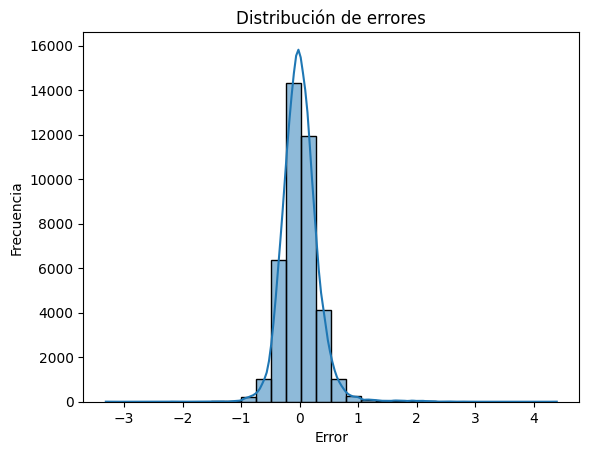

In [438]:
# Distribución de los errores Test
errores = metricas_sgd['y_test_flat'] - metricas_sgd['y_pred_test_flat']
sns.histplot(errores, kde=True, bins=30)
plt.title("Distribución de errores")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

#### Mini-Bach Gradient Descent

In [439]:
# Cálculo del batch size
batch_size = int(np.sqrt(len(X_train_scaler)))
batch_size

397

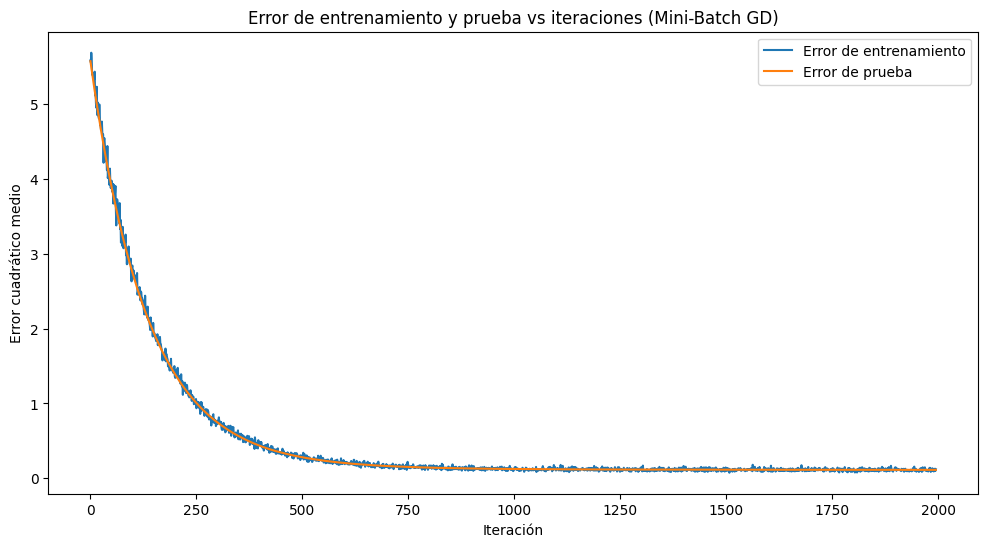

In [440]:
mbgd_coef = mini_batch_gradient_descent(X_train_scaler, y_train, X_test_scaler, y_test,lr=0.001, epochs=5, batch_size=batch_size)

In [441]:
mbgd_coef

array([[ 1.28348597],
       [ 0.20391492],
       [ 0.42411036],
       [-0.00631049],
       [ 0.03579691],
       [ 0.03253863],
       [ 0.02620692],
       [ 0.0106819 ],
       [ 0.00165829],
       [ 0.02927993],
       [ 0.04764697],
       [ 0.06893128],
       [ 0.08049546],
       [ 0.05208624],
       [ 0.0475928 ],
       [ 0.07653355],
       [ 0.06922862],
       [ 0.05758597],
       [ 0.05768447],
       [ 0.05065382],
       [ 0.05357881],
       [ 0.06035384],
       [ 0.06206774],
       [ 0.0693937 ],
       [ 0.06878854],
       [ 0.0609757 ],
       [ 0.05111262],
       [ 1.0491083 ],
       [ 0.23320199]])

Analizamos las métricas

Mini-Batch GD - Entrenamiento → RMSE: 0.3337 | R²: 0.6021
Mini-Batch GD - Test         → RMSE: 0.3344 | R²: 0.6011

Ordenada al origen: 1.2835


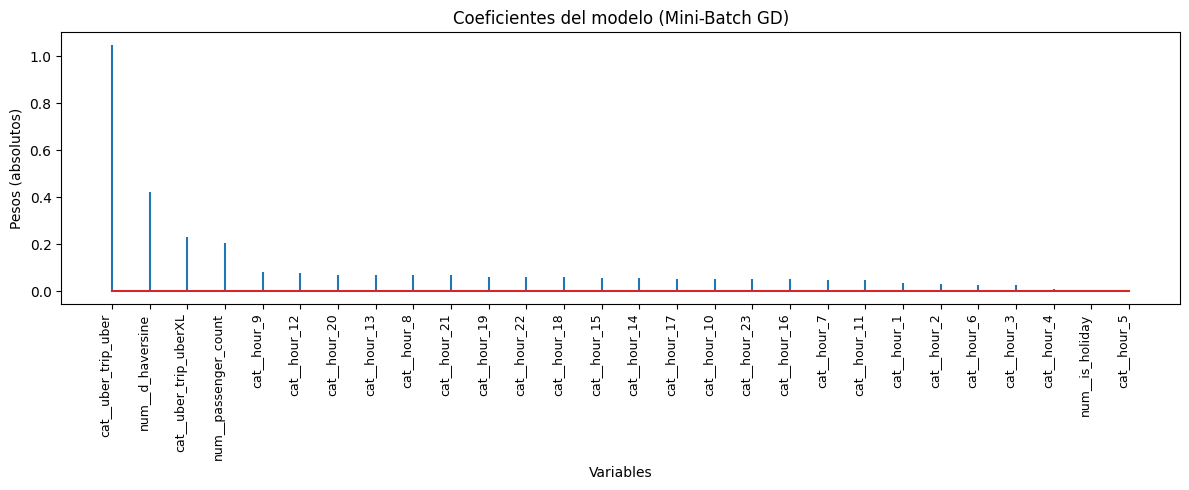

In [442]:
metricas_mbgd = evaluar_modelo(mbgd_coef, X_train_scaler, X_test_scaler, y_train, y_test, pipeline, titulo='Mini-Batch GD')

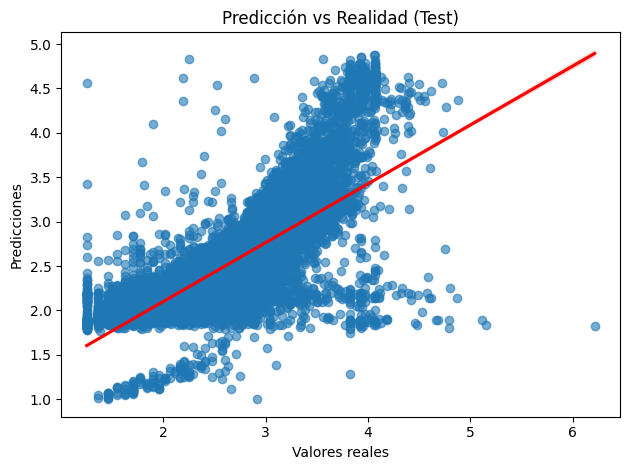

In [443]:
# Predicción vs Realidad
sns.regplot(x=metricas_mbgd['y_test_flat'], y=metricas_sgd['y_pred_test_flat'], line_kws={'color': 'red'}, scatter_kws={'alpha':0.6})
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicción vs Realidad (Test)")
plt.tight_layout()
plt.show()

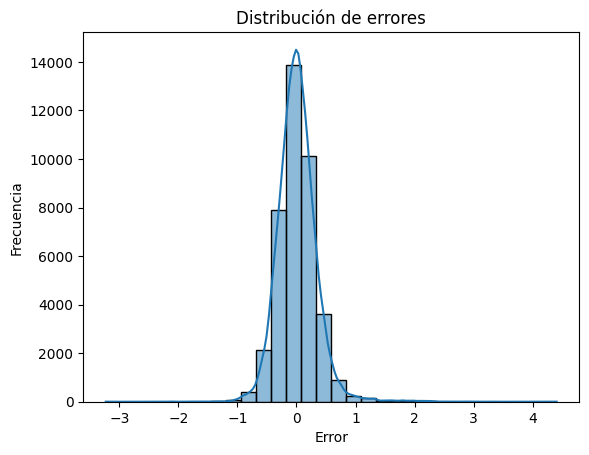

In [444]:
# Distribución de los errores Test
errores = metricas_mbgd['y_test_flat'] - metricas_mbgd['y_pred_test_flat']
sns.histplot(errores, kde=True, bins=30)
plt.title("Distribución de errores")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

# Regularizacion

##Funciones

In [445]:
def graficar_coeficientes(coef, feature_names, titulo='Coeficientes del Modelo'):
    """
    Grafica los coeficientes absolutos de un modelo lineal.
    """
    # Creamos el DF
    df_coef = pd.DataFrame({
        'predictor': feature_names,
        'coef': abs(coef)
    }).sort_values(by='coef', ascending=False)

    # Grafica
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.stem(df_coef.predictor, df_coef.coef, markerfmt=' ')
    plt.xticks(rotation=90, ha='right', size=10)
    ax.set_xlabel('Feature')
    ax.set_ylabel('Pesos [abs]')
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

In [446]:
def calcular_metricas(modelo, X_train, y_train, X_test, y_test, nombre='Modelo'):
    """
    Calcula y muestra RMSE y R² para entrenamiento y testeo.

    A destacar: Como parámetro pasamos el modelo entrenado
    """
    y_pred_train = modelo.predict(X_train).reshape(-1,1)
    y_pred_test = modelo.predict(X_test).reshape(-1,1)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    r2_train = r2_score(y_train, y_pred_train)

    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)

    print(f"{nombre} - Entrenamiento → RMSE: {rmse_train:.4f} | R²: {r2_train:.4f}")
    print(f"{nombre} - Test         → RMSE: {rmse_test:.4f} | R²: {r2_test:.4f}\n")

    return {
        'rmse_train': rmse_train,
        'r2_train': r2_train,
        'rmse_test': rmse_test,
        'r2_test': r2_test,
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test
    }

##Regularizacion Ridge

Coeficientes: [ 1.35232582e-02  4.33993250e-01 -6.36733181e-03 -1.37906022e-02
 -2.41614464e-02 -2.01115929e-02 -2.18410972e-02 -6.10729327e-02
 -7.67123700e-02 -1.70150141e-02  3.53185443e-02  5.29624580e-02
  4.58244889e-02  4.88076341e-02  5.83992877e-02  4.50153052e-02
  5.26139236e-02  4.97339234e-02  2.52021345e-02  4.35706391e-02
  3.95173853e-02  2.33050922e-02 -5.56224284e-05 -3.69305353e-03
  4.98663266e-03  5.57855099e-03  6.69858850e-02  3.43359103e-02]

Ordenada al origen: [2.23588471]

Ridge - Entrenamiento → RMSE: 0.3047 | R²: 0.6681
Ridge - Test         → RMSE: 0.3050 | R²: 0.6682



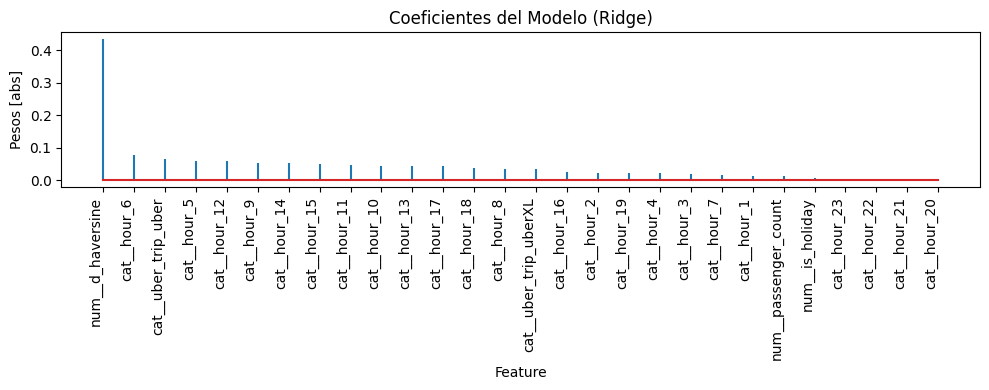

In [447]:
# Creamos un modelo basado en una regresion lineal
ridge = Ridge(alpha=0.5) # Parametro de regularizacion, falta optimizacion con validacion cruzada

# Ajustamos el modelo a los datos
ridge.fit(X_train_scaler, y_train)

# Coeficientes
print(f'Coeficientes: {ridge.coef_}')
print(f'\nOrdenada al origen: {ridge.intercept_}\n')

metricas_ridge = calcular_metricas(ridge, X_train_scaler, y_train, X_test_scaler, y_test, nombre='Ridge')

# Graficamos coeficientes
graficar_coeficientes(ridge.coef_, feature_names, titulo='Coeficientes del Modelo (Ridge)')

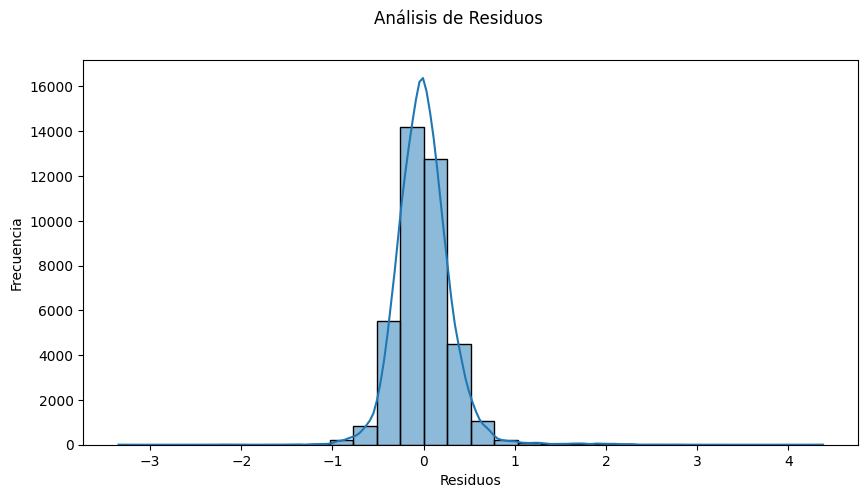

In [448]:
# Graficamos la distribución de los residuos con datos de testeo
fig = plt.figure(figsize=(10,5))
sns.histplot((y_test - metricas_ridge['y_pred_test']), color="blue", kde=True,bins=30, legend=False)
fig.suptitle('Análisis de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

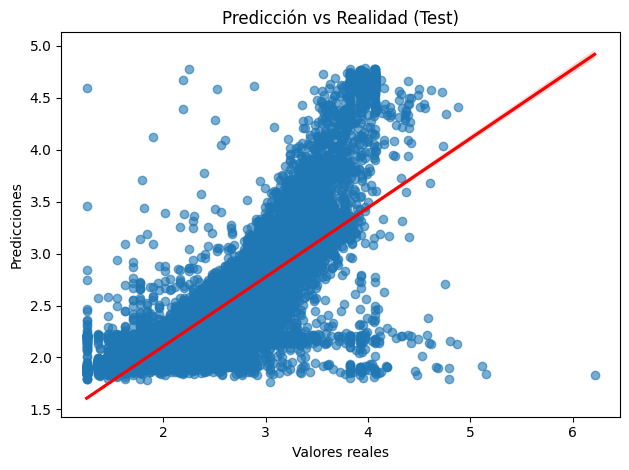

In [449]:
# Predicción vs Realidad
sns.regplot(x=y_test, y=metricas_ridge['y_pred_test'], line_kws={'color': 'red'}, scatter_kws={'alpha':0.6})
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicción vs Realidad (Test)")
plt.tight_layout()
plt.show()


##Ridge con Validacion Cruzada

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


Coeficientes: [ 0.01363614  0.43388467 -0.0063706  -0.01493632 -0.02519441 -0.02110935
 -0.02269048 -0.06104955 -0.07725602 -0.01816843  0.03392754  0.05149875
  0.04438097  0.04735842  0.05691944  0.0435876   0.0511605   0.04828906
  0.02384312  0.04214649  0.03813328  0.02197783 -0.00130942 -0.00493055
  0.00373172  0.00432281  0.06202541  0.02899905]

Ordenada al origen: [2.24211555]

Mejor alpha: 30.01835813575592

RidgeCV - Entrenamiento → RMSE: 0.3047 | R²: 0.6681
RidgeCV - Test         → RMSE: 0.3050 | R²: 0.6682



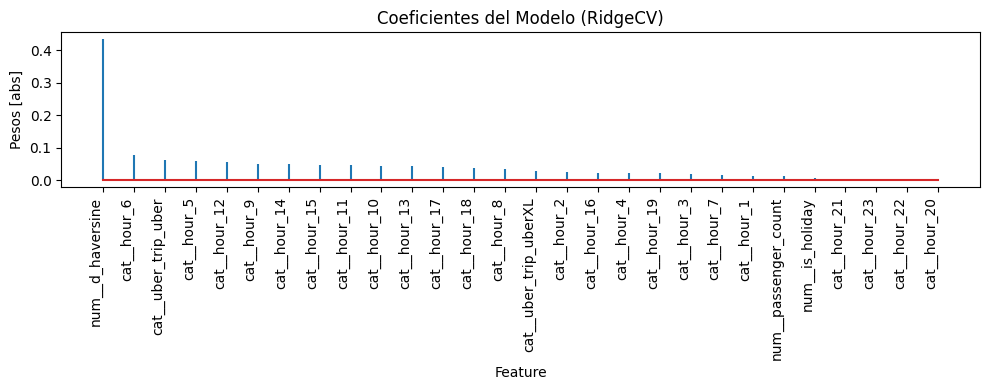

In [450]:
# Instanciamos el modelo
ridgeCV = RidgeCV(alphas = np.logspace(-3, 6, 200), fit_intercept = True, store_cv_values = True)

# Entrenamos
ridgeCV.fit(X_train_scaler, y_train)

# Métricas
print(f'Coeficientes: {ridgeCV.coef_}')
print(f'\nOrdenada al origen: {ridgeCV.intercept_}')
print(f'\nMejor alpha: {ridgeCV.alpha_}\n')

metricas_ridgeCV = calcular_metricas(ridgeCV, X_train_scaler, y_train, X_test_scaler, y_test, nombre='RidgeCV')

# Graficamos coeficientes
graficar_coeficientes(ridgeCV.coef_, feature_names, titulo='Coeficientes del Modelo (RidgeCV)')

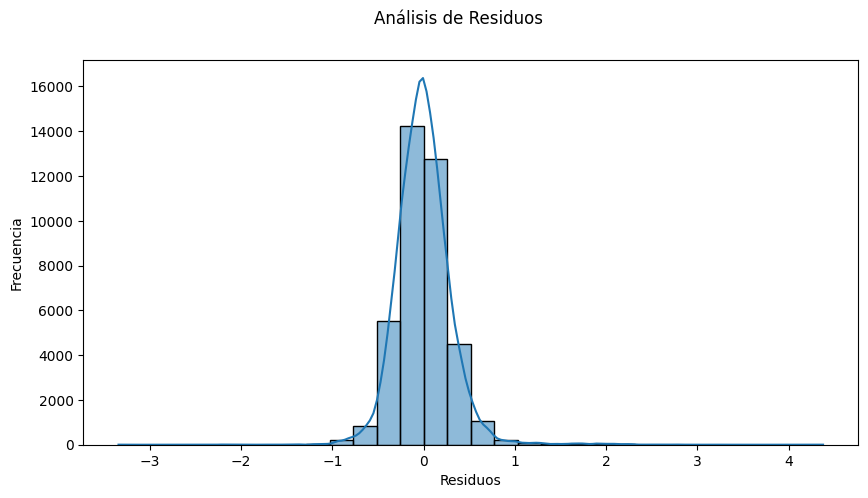

In [451]:
# Graficamos la distribución de los residuos con datos de testeo
fig = plt.figure(figsize=(10,5))
sns.histplot((y_test - metricas_ridgeCV['y_pred_test']), color="blue", kde=True,bins=30, legend=False)
fig.suptitle('Análisis de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

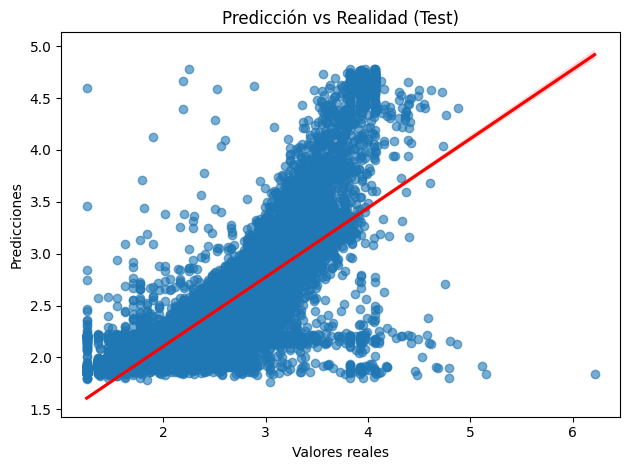

In [452]:
# Predicción vs Realidad
sns.regplot(x=y_test, y=metricas_ridgeCV['y_pred_test'], line_kws={'color': 'red'}, scatter_kws={'alpha':0.6})
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicción vs Realidad (Test)")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:110: FutureWarning: Attribute `cv_values_` is deprecated in version 1.5 and will be removed in 1.7. Use `cv_results_` instead.
  warnings.warn(msg, category=FutureWarning)


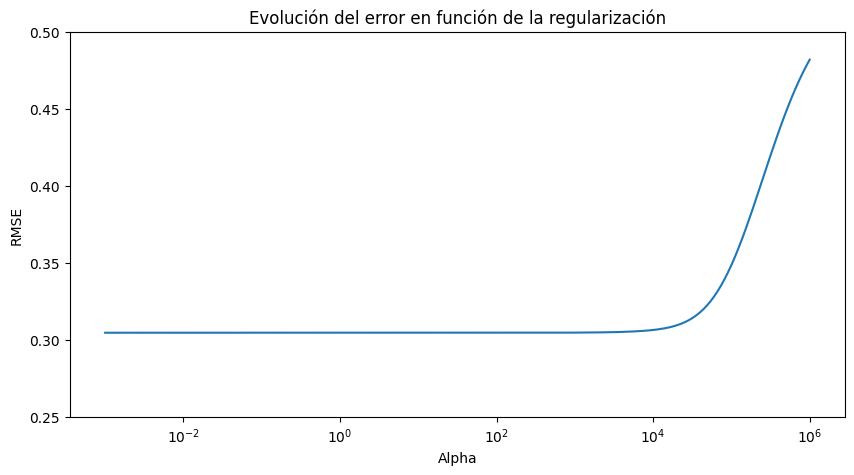

In [453]:
# Evolución del error de validación cruzada en función de Alpha
mse_cv = ridgeCV.cv_values_.reshape((-1, 200)).mean(axis=0)

# Se aplica la raíz cuadrada para pasar de MSE a RMSE
rmse_cv = np.sqrt(mse_cv)

# Se identifica el mejor
min_rmse = np.min(rmse_cv)
optimo = ridgeCV.alphas[np.argmin(rmse_cv)]

#Visualizacion de como evoluciona el rmse con respecto a todos los valores alpha aplicados
plt.figure(figsize=(10, 5))
ax = plt.gca()
ax.plot(ridgeCV.alphas, rmse_cv)
ax.set_ylim([0.25, 0.5])
ax.set_xscale('log')
ax.set_title('Evolución del error en función de la regularización')
ax.set_xlabel('Alpha')
ax.set_ylabel('RMSE')
plt.show()

##Regularizacion Lasso

Coeficientes: [ 0.          0.33123555 -0.         -0.         -0.         -0.
  0.         -0.         -0.         -0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.         -0.         -0.         -0.
 -0.         -0.         -0.          0.        ]

Ordenada al origen: [2.32118637]

Lasso - Entrenamiento → RMSE: 0.3223 | R²: 0.6288
Lasso - Test         → RMSE: 0.3225 | R²: 0.6289



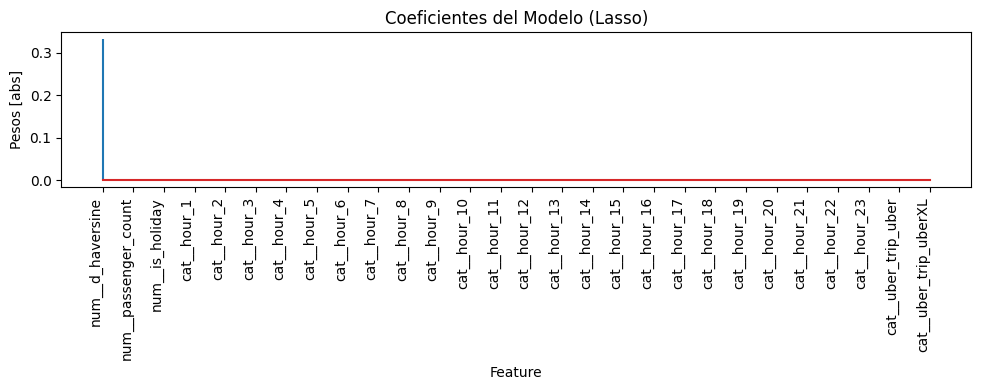

In [454]:
# Instanciamos el modelo
lasso = Lasso(alpha=0.1)

# Entrenamos
lasso.fit(X_train_scaler, y_train)

# Métricas
print(f'Coeficientes: {lasso.coef_}')
print(f'\nOrdenada al origen: {lasso.intercept_}\n')

metricas_lasso = calcular_metricas(lasso, X_train_scaler, y_train, X_test_scaler, y_test, nombre='Lasso')

# Graficamos coeficientes

graficar_coeficientes(lasso.coef_, feature_names, titulo='Coeficientes del Modelo (Lasso)')

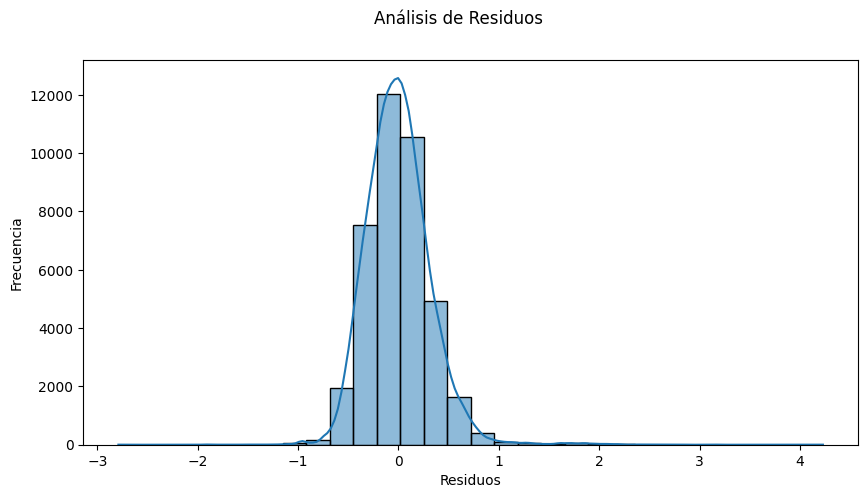

In [455]:
# Graficamos la distribución de los residuos con datos de testeo
fig = plt.figure(figsize=(10,5))
sns.histplot((y_test - metricas_lasso['y_pred_test']), color="blue", kde=True,bins=30, legend=False)
fig.suptitle('Análisis de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

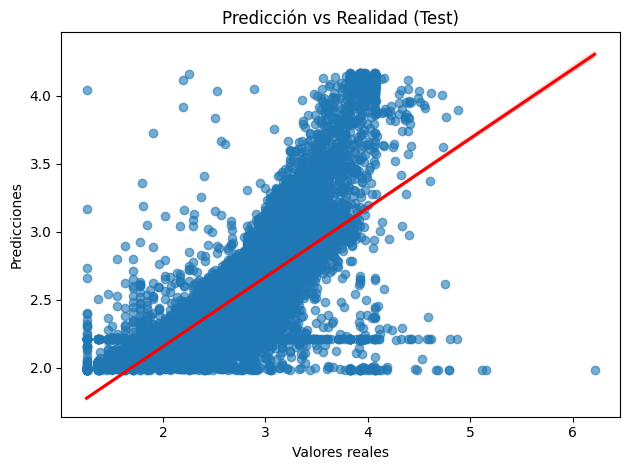

In [456]:
# Predicción vs Realidad
sns.regplot(x=y_test, y=metricas_lasso['y_pred_test'], line_kws={'color': 'red'}, scatter_kws={'alpha':0.6})
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicción vs Realidad (Test)")
plt.tight_layout()
plt.show()

##Lasso con Validacion Cruzada

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Coeficientes: [ 0.00450709  0.43069639 -0.00541291 -0.         -0.         -0.
 -0.         -0.         -0.04960823 -0.01036737  0.          0.01033526
  0.0026452   0.00671357  0.01765436  0.00443822  0.01156864  0.00866273
  0.          0.0027862   0.00244052  0.         -0.00307037 -0.00608133
 -0.         -0.          0.         -0.        ]

Ordenada al origen: 2.319848825326059

Mejor alpha: 0.001

LassoCV - Entrenamiento → RMSE: 0.3057 | R²: 0.6661
LassoCV - Test         → RMSE: 0.3058 | R²: 0.6665



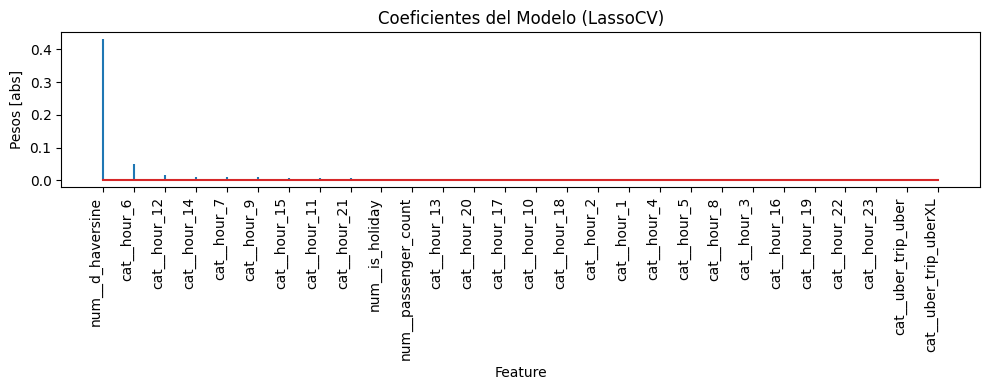

In [457]:
# Instanciamos el modelo
lassoCV = LassoCV(alphas = np.logspace(-3, 6, 200), fit_intercept = True, cv = 10)  # realizamos una validación cruzada de 10 particiones

# Entrenamos
lassoCV.fit(X_train_scaler, y_train)

# Métricas
print(f'Coeficientes: {lassoCV.coef_}')
print(f'\nOrdenada al origen: {lassoCV.intercept_}')
print(f'\nMejor alpha: {lassoCV.alpha_}\n')

metricas_lassoCV = calcular_metricas(lassoCV, X_train_scaler, y_train, X_test_scaler, y_test, nombre='LassoCV')

# Graficamos coeficientes
graficar_coeficientes(lassoCV.coef_, feature_names, titulo='Coeficientes del Modelo (LassoCV)')

El modelo LassoCV selecciona automáticamente el valor óptimo de alpha mediante validación cruzada. Recordar que el parámetro alpha controla la fuerza de la regularización.

A diferencia del Lasso con alpha fijo, que llevó todos los coeficientes a cero (posible sobreajuste a la regularización), LassoCV conservó variables relevantes y mejoró un poco el desempeño del modelo en términos de RMSE y R², tanto en entrenamiento como en test.


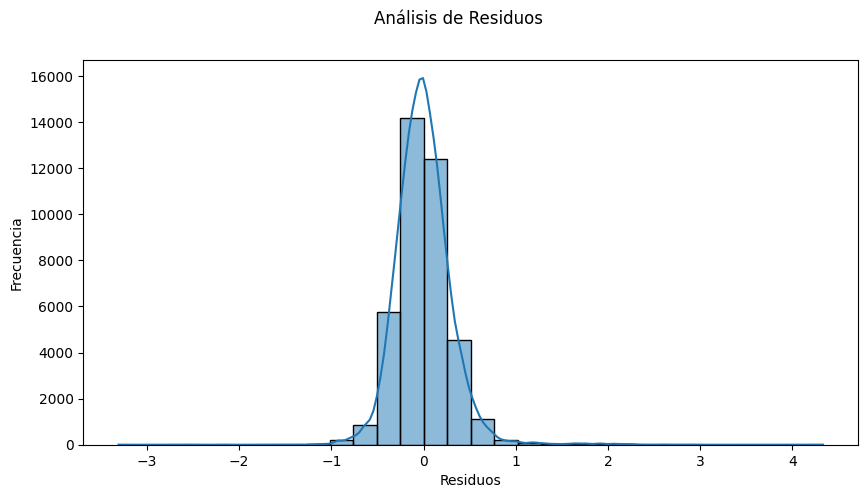

In [458]:
# Graficamos la distribución de los residuos con datos de testeo
fig = plt.figure(figsize=(10,5))
sns.histplot((y_test - metricas_lassoCV['y_pred_test']), color="blue", kde=True,bins=30, legend=False)
fig.suptitle('Análisis de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

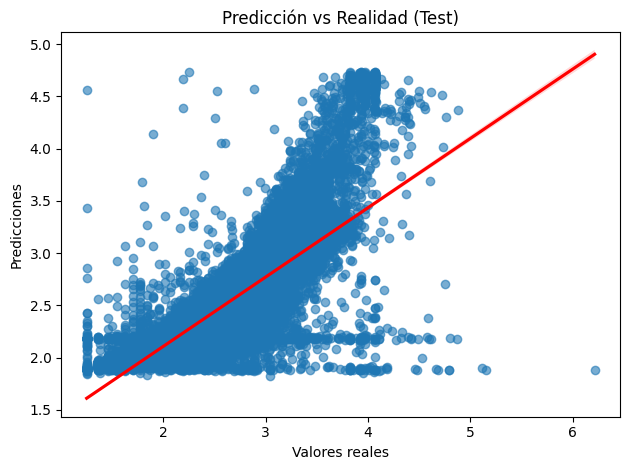

In [459]:
# Predicción vs Realidad
sns.regplot(x=y_test, y=metricas_lassoCV['y_pred_test'], line_kws={'color': 'red'}, scatter_kws={'alpha':0.6})
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicción vs Realidad (Test)")
plt.tight_layout()
plt.show()

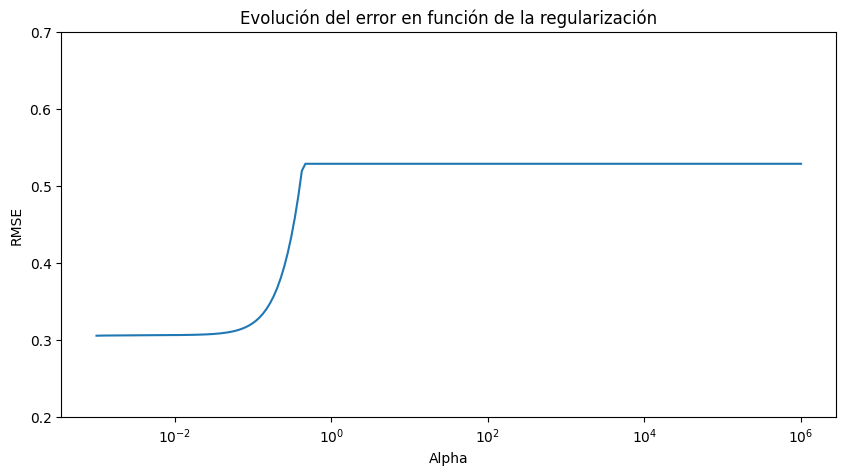

In [460]:
# Evolución del error de validación cruzada en función de Alpha
mse_cv = lassoCV.mse_path_.mean(axis=1)

# Se aplica la raíz cuadrada para pasar de MSE a RMSE
rmse_cv = np.sqrt(mse_cv)

# Se identifica el mejor RMSE
min_rmse     = np.min(rmse_cv)
optimo       = lassoCV.alphas_[np.argmin(rmse_cv)]

# Graficamos
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(lassoCV.alphas_, rmse_cv)
ax.set_xscale('log')
ax.set_ylim([0.2,0.7])
ax.set_title('Evolución del error en función de la regularización')
ax.set_xlabel('Alpha')
ax.set_ylabel('RMSE')
plt.show()

## ElasticNet

Coeficientes: [ 0.          0.36308147 -0.         -0.         -0.         -0.
 -0.         -0.         -0.         -0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.         -0.         -0.         -0.
 -0.         -0.         -0.          0.        ]

Ordenada al origen: [2.32118637]

ElasticNet - Entrenamiento → RMSE: 0.3139 | R²: 0.6479
ElasticNet - Test         → RMSE: 0.3141 | R²: 0.6482



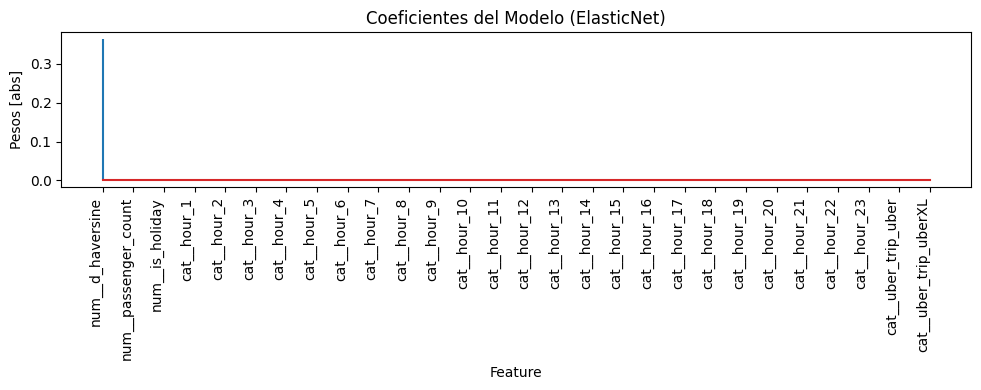

In [461]:
# Instanciamos el modelo, balance entre las penalizaciones L1 (Lasso) y L2 (Ridge)
elasticnet = ElasticNet(alpha=0.1, l1_ratio=0.5)

# Entrenamos
elasticnet.fit(X_train_scaler, y_train)

# Metricas
print(f'Coeficientes: {elasticnet.coef_}')
print(f'\nOrdenada al origen: {elasticnet.intercept_}\n')

metricas_elasticnet = calcular_metricas(elasticnet, X_train_scaler, y_train, X_test_scaler, y_test, nombre='ElasticNet')

# Graficamos coeficientes
graficar_coeficientes(elasticnet.coef_, feature_names, titulo='Coeficientes del Modelo (ElasticNet)')

El parámetro alpha controla la fuerza de la regularización. En este caso se eligió uno al azar. Podemos observar que con el alpha seleccionado, la regularización fue fuerte y provocó que solo una variable resultara relevante para el modelo.

## ElasticNetCV

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Coeficientes: [ 0.00816806  0.43181299 -0.00591022 -0.01134373 -0.01620179 -0.00411484
 -0.         -0.02185521 -0.06680767 -0.01871111  0.00837522  0.02605193
  0.01874778  0.02224212  0.03241215  0.01925998  0.02659916  0.02372561
  0.          0.0177759   0.01561438  0.         -0.0066999  -0.00995088
 -0.0007852  -0.          0.0126717  -0.        ]

Ordenada al origen: 2.303478450703075

Alpha utilizado: 0.001

l1_ratio utilizado: 0.5

ElasticNetCV - Entrenamiento → RMSE: 0.3051 | R²: 0.6674
ElasticNetCV - Test         → RMSE: 0.3053 | R²: 0.6676



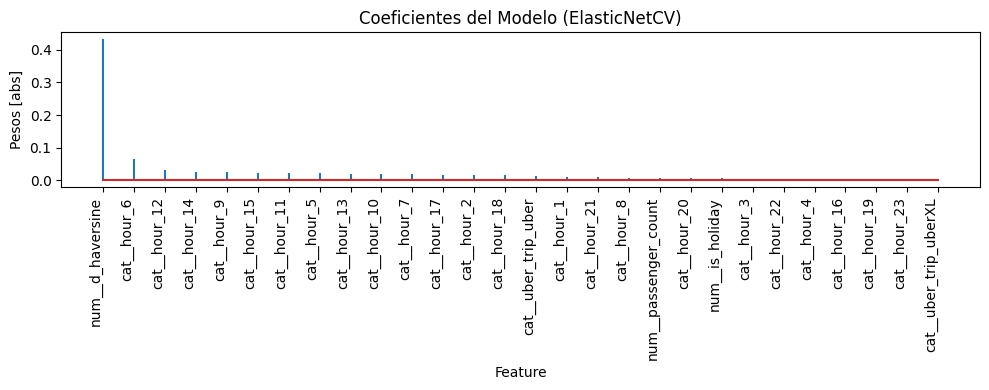

In [462]:
# Instanciamos el modelo
elasticnetCV = ElasticNetCV(alphas = np.logspace(-3, 6, 200), fit_intercept = True, cv = 10) # realizamos una validación cruzada de 10 particiones

# Entrenamos
elasticnetCV.fit(X_train_scaler, y_train)

# Metricas
print(f'Coeficientes: {elasticnetCV.coef_}')
print(f'\nOrdenada al origen: {elasticnetCV.intercept_}\n')
print(f'Alpha utilizado: {elasticnetCV.alpha_}\n')
print(f'l1_ratio utilizado: {elasticnetCV.l1_ratio_}\n')

metricas_elasticnetCV = calcular_metricas(elasticnetCV, X_train_scaler, y_train, X_test_scaler, y_test, nombre='ElasticNetCV')

# Graficamos coeficientes
graficar_coeficientes(elasticnetCV.coef_, feature_names, titulo='Coeficientes del Modelo (ElasticNetCV)')

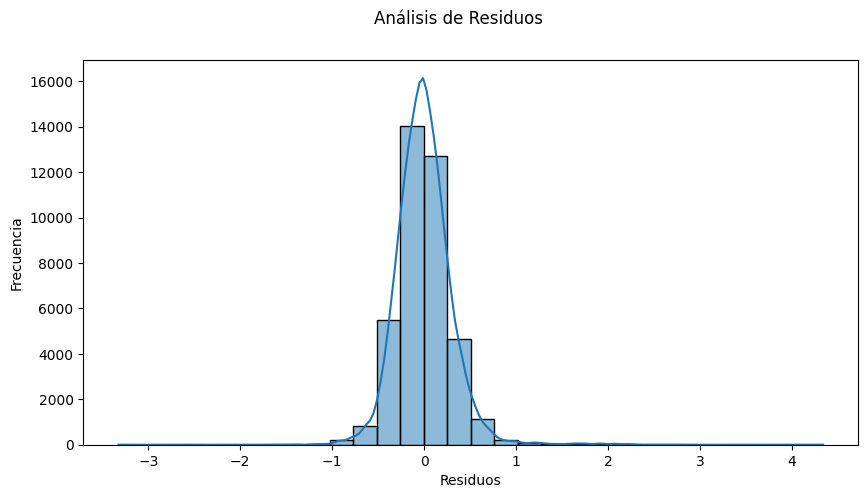

In [463]:
# Graficamos la distribución de los residuos con datos de testeo
fig = plt.figure(figsize=(10,5))
sns.histplot((y_test - metricas_elasticnetCV['y_pred_test']), color="blue", kde=True,bins=30, legend=False)
fig.suptitle('Análisis de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

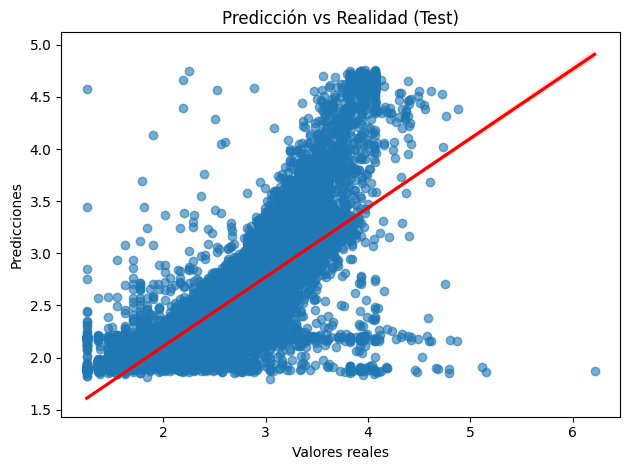

In [464]:
# Predicción vs Realidad
sns.regplot(x=y_test, y=metricas_elasticnetCV['y_pred_test'], line_kws={'color': 'red'}, scatter_kws={'alpha':0.6})
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicción vs Realidad (Test)")
plt.tight_layout()
plt.show()

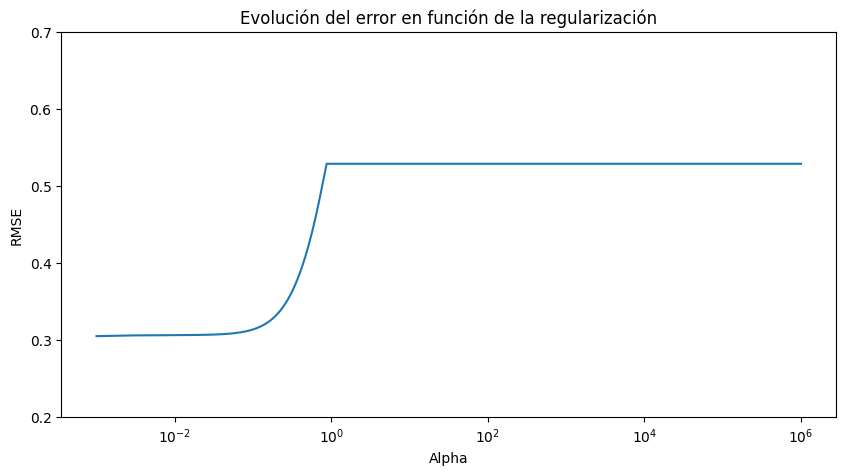

In [465]:
# Evolución del error de validación cruzada en función de Alpha
mse_cv = elasticnetCV.mse_path_.mean(axis=1)

# Se aplica la raíz cuadrada para pasar de MSE a RMSE
rmse_cv = np.sqrt(mse_cv)

# Se identifica el mejor RMSE
min_rmse     = np.min(rmse_cv)
optimo       = elasticnetCV.alphas_[np.argmin(rmse_cv)]

# Graficamos
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(elasticnetCV.alphas_, rmse_cv)
ax.set_xscale('log')
ax.set_ylim([0.2,0.7])
ax.set_title('Evolución del error en función de la regularización')
ax.set_xlabel('Alpha')
ax.set_ylabel('RMSE')
plt.show()

#Conclusiones

In [466]:
metricas_modelos = {
    'LinearRegression': metricas_lr,
    'Ridge': metricas_ridge,
    'RidgeCV': metricas_ridgeCV,
    'Lasso': metricas_lasso,
    'LassoCV': metricas_lassoCV,
    'ElasticNet': metricas_elasticnet,
    'ElasticNetCV': metricas_elasticnetCV
}

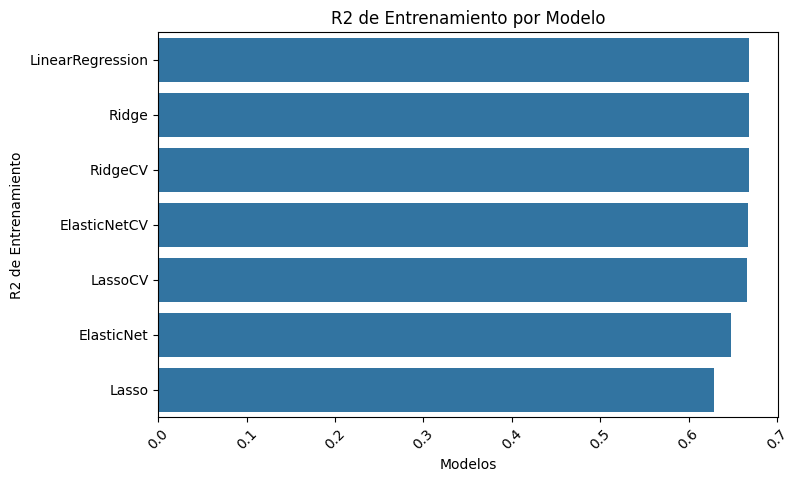

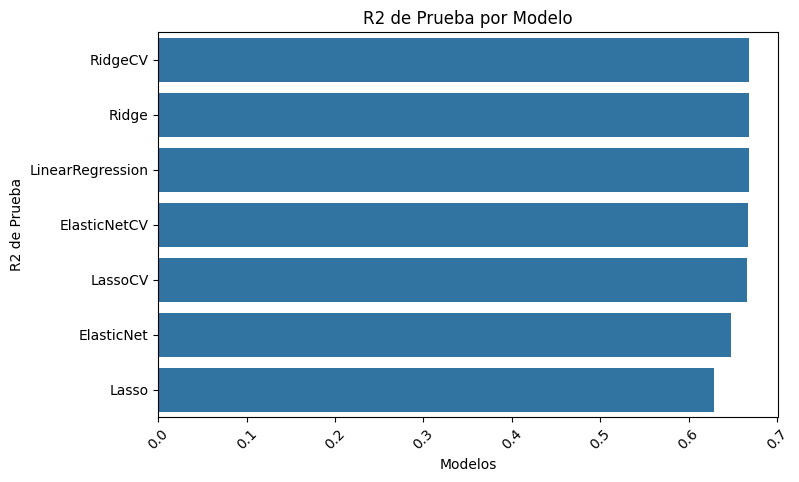

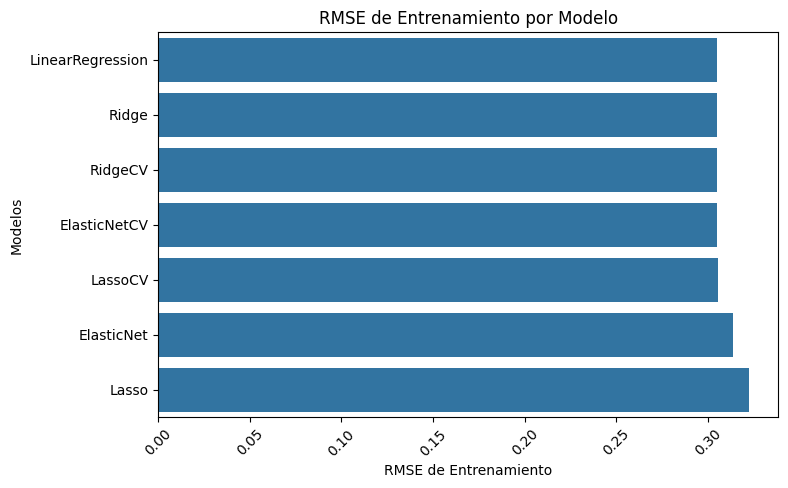

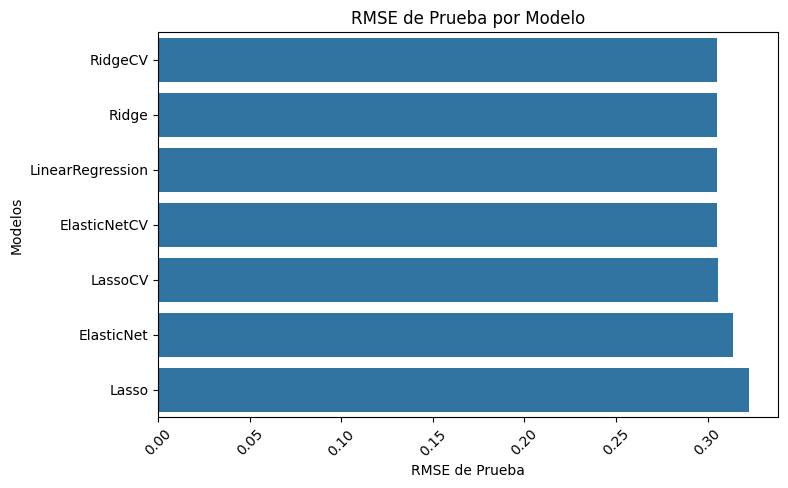

In [467]:
# Convertmos el diccionario en un DF
df_metricas = pd.DataFrame(metricas_modelos).T

# Filtramos
df_metricas_r2_train = df_metricas[['r2_train']].sort_values(by='r2_train', ascending=False)
df_metricas_r2_test = df_metricas[['r2_test']].sort_values(by='r2_test', ascending=False)

# Graficamos R2 de entrenamiento
plt.figure(figsize=(8, 5))
sns.barplot(y=df_metricas_r2_train.index, x=df_metricas_r2_train['r2_train'])
plt.title('R2 de Entrenamiento por Modelo')
plt.ylabel('R2 de Entrenamiento')
plt.xlabel('Modelos')
plt.xticks(rotation=45)
plt.show()

# Graficamos R2 de prueba
plt.figure(figsize=(8, 5))
sns.barplot(y=df_metricas_r2_test.index, x=df_metricas_r2_test['r2_test'])
plt.title('R2 de Prueba por Modelo')
plt.ylabel('R2 de Prueba')
plt.xlabel('Modelos')
plt.xticks(rotation=45)
plt.show()

# Filtramos por RMSE
df_metricas_rmse_train = df_metricas[['rmse_train']].sort_values(by='rmse_train', ascending=True)
df_metricas_rmse_test = df_metricas[['rmse_test']].sort_values(by='rmse_test', ascending=True)

# Graficamos RMSE de entrenamiento
plt.figure(figsize=(8, 5))
sns.barplot(y=df_metricas_rmse_train.index, x=df_metricas_rmse_train['rmse_train'])
plt.title('RMSE de Entrenamiento por Modelo')
plt.xlabel('RMSE de Entrenamiento')
plt.ylabel('Modelos')
plt.xticks(rotation=45)
plt.show()

# Graficamos RMSE de prueba
plt.figure(figsize=(8, 5))
sns.barplot(y=df_metricas_rmse_test.index, x=df_metricas_rmse_test['rmse_test'])
plt.title('RMSE de Prueba por Modelo')
plt.xlabel('RMSE de Prueba')
plt.ylabel('Modelos')
plt.xticks(rotation=45)
plt.show()




**Entrenamiento:**

*   Un R² más alto indica que el modelo explica una mayor proporción de la variabilidad de la variable dependiente, que es la variable que queremos predecir.
*   Un RMSE más bajo indica que los errores de predicción son, en promedio, menores.

Podemos observar que la regresión lineal obtiene los mejores resultados tanto en R2 obteniendo el valor grande como en RSME obteniendo el valor mas chico.

**Prueba:**

*   R² más alto en test indica que el modelo generaliza mejor a datos no vistos.
*   RMSE más bajo en test indica que el promedio de los errores de predicción es menor que en los demás modelos.

Para los datos de prueba, observamos que el que tiene mejor performance fue RidgeCV, siendo el que obtuvo mejor resultado en R2, siendo el valor mas grande y en RMSE obteniendo el valor mas chico.

**Conclusión:**

Aunque la regresión lineal obtuvo los mejores resultados en el entrenamiento, su rendimiento fue un poco menor usando datos de prueba(no vistos). En cambio, RidgeCV muestra un mejor comportamiento en datos no vistos (test).

**Elegimos como mejor opcion el modelo generado por RidgeCV.**


**Observaciones:**

En todos los gráficos de dispersión que comparan las predicciones del modelo (y_pred_test) con los valores reales (y_test), se observa una alta dispersión, con muchos puntos alejados de la línea de referencia (donde predicción = valor real).

En el rango de valores reales entre 3 y 4, el modelo tiende a realizar sobreestimaciones, es decir, predice valores mayores a los reales.
En cambio, entre 4 y 5, ocurre lo contrario: se observan subestimaciones, donde las predicciones están significativamente por debajo de los valores reales.

Este patrón indica que el modelo no logra capturar adecuadamente la relación en esos tramos del target, y que su capacidad predictiva varía según el rango de valores.

**Variacion de hiperparametros:**

Alpha es el hiperparámetro que controla el nivel de penalización en los modelos.

Al observar cómo varía el error en función del parámetro de regularización alpha, notamos que en LassoCV y ElasticNetCV se producen transiciones abruptas. Pequeños cambios en alpha generan saltos importantes en el error. Esto se debe a que ambos modelos tienden a eliminar variables a medida que aumenta la penalización.

En cambio, en RidgeCV, el cambio en el error es más progresivo, ya que penaliza sin forzar los coeficientes a cero, haciendo que el modelo se ajuste de forma más suave frente a cambios en alpha.




